# 01 — Shared Data Preparation

**Purpose.** Turn the provided metadata and images into one auditable,
leakage-safe data contract for all later notebooks.

**Scope.** This notebook audits files, reconciles IDs, checks image integrity,
finds duplicate/family relationships, verifies the protected split, prepares five
development folds, describes development labels, and publishes evidence.

**Out of scope.** It does not train a model, choose a metric, choose a final image
transform, fit model statistics, create a search index, or inspect holdout labels.

The narrative pattern is: **Purpose → Code → output below the code → Finding**. Small setup cells are explained briefly; complex audit cells show
their evidence path, row count, and SHA-256 where useful.


## 1. Dataset understanding, scope, and execution contract

**Purpose.** Establish what the supplied dataset does and does not document,
define the allowed teacher-only input boundary, and make the execution contract
visible before inspecting or transforming any data.


### 1.1 Dataset description and documentation limitations

The assignment brief provides a **basic dataset description**: fashion e-commerce
product images, approximate train and prediction sizes, the available metadata fields,
the ID-to-image relationship, and an education-only use boundary. The inventory below
audits the exact files that were delivered. However, a schema is not a full account of
how or why a dataset was created.

| Documentation area | What is known from the brief or supplied files | What remains unknown |
|---|---|---|
| Purpose | The assignment defines four prediction/retrieval tasks. | The original business decision or research purpose for collecting the catalogue is not stated. |
| Collection | The files represent fashion products and include catalogue metadata. | The retailer/platform, geographic market, sampling rule, collection dates, and inclusion/exclusion process are not stated. |
| Labels | Column names and observed class values are available. | Annotation instructions, annotator count, quality control, and operational definitions of Season, Gender, and Usage are not stated. |
| Images | Product IDs map to image filenames, and later audit cells measure the delivered bytes and geometry. | The capture, editing, resizing, background, and compression pipeline before delivery is not stated. |
| Population | The delivered catalogue can be described exactly. | There is no evidence that it represents all fashion products, customers, regions, seasons, or real-world camera conditions. |

These unknowns limit the claims that later tasks may make. Labels are treated as
**catalogue labels**, not objective or causal truths. Dataset-level patterns cannot be
generalised to all customers or fashion markets without new external evidence. A model
that works on similar catalogue images may still fail after a retailer, camera,
compression process, or labelling policy changes.

The mitigation is to preserve source provenance, keep protected evaluation separate,
measure class/group support, test shortcuts and robustness, report failure slices, and
state a narrow deployment scope. No undocumented collection detail is guessed or
silently filled in.

This limitation record follows the questions proposed by
[Gebru et al. (2021), *Datasheets for Datasets*](https://doi.org/10.1145/3458723):
motivation, composition, collection process, recommended uses, and limitations should
travel with a dataset. The local factual source is the
[assignment brief](../docs/COSC2753_2026B_Assignment%202.pdf); everything absent from
that brief or the supplied files remains explicitly unknown.


### 1.2 Runtime setup

**Purpose.** Resolve the repository without a machine-specific path, load only the
shared data API, and define small display/write helpers. The helpers do not make
modelling decisions.

**Outside helpers loaded here.** Imports come from `src/fashion/config.py`,
`src/fashion/data/audit.py`, `src/fashion/data/dataset.py`,
`src/fashion/data/evidence.py`, `src/fashion/data/hashing.py`,
`src/fashion/data/pipeline.py`, and `src/fashion/data/splits.py`. Later sections
name the exact helper file again where each helper is called.


#### 1.2.1 Project root and core imports

In [1]:
from __future__ import annotations

import hashlib
import inspect
import json
import os
import subprocess
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, ImageOps


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src/fashion").is_dir():
            return candidate
    raise RuntimeError("Could not locate the project root")


ROOT = find_project_root(Path.cwd())
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

print(f"Project root resolved: {ROOT.name}")


Project root resolved: MLA2


**Finding.** The notebook finds `MLA2-eda` from `pyproject.toml` and `src/fashion`, so it can run from the repository or notebook folder. This avoids a hidden machine-specific path and keeps the saved notebook portable.

#### 1.2.2 Shared data API and constants

In [2]:
from fashion.config import RANDOM_SEED, TARGET_COLUMNS  # noqa: E402
from fashion.data.audit import audit_image  # noqa: E402
from fashion.data.dataset import iter_cv_folds, load_splits  # noqa: E402
from fashion.data.evidence import (  # noqa: E402
    article_target_heatmap,
    family_profile,
    fold_support_tables,
    near_threshold_review,
    shortcut_benchmarks,
)
from fashion.data.hashing import compute_sha256  # noqa: E402
from fashion.data.pipeline import validate_prepared_data_cache  # noqa: E402
from fashion.data.splits import cv_assignment_digest  # noqa: E402

TARGETS = tuple(TARGET_COLUMNS)
EVIDENCE_DIR = ROOT / "results/evidence/data_preparation"
FIGURE_DIR = ROOT / "results/figures/data_preparation"
EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Seed: {RANDOM_SEED} | targets: {', '.join(TARGETS)}")


Seed: 2753 | targets: articleType, season, gender, usage


**Finding.** Seed 2753 and the four targets (`articleType`, `season`, `gender`, and `usage`) come from the shared package. Later notebooks therefore use the same constants and prepared-data helpers instead of quietly defining new ones.

#### 1.2.3 Evidence writers

In [3]:
def relative(path: Path) -> str:
    logical_path = path if path.is_absolute() else ROOT / path
    return logical_path.absolute().relative_to(ROOT).as_posix()


def sha256_file(path: Path) -> str:
    return compute_sha256(path)


def write_table(frame: pd.DataFrame, filename: str) -> str:
    path = EVIDENCE_DIR / filename
    frame.to_csv(path, index=False, lineterminator="\n")
    print(f"Wrote {relative(path)} | rows={len(frame):,} | sha256={sha256_file(path)}")
    return relative(path)


def save_figure(figure: plt.Figure, filename: str) -> dict[str, str]:
    path = FIGURE_DIR / filename
    figure.savefig(path, dpi=180, bbox_inches="tight")
    return {"repository_path": relative(path), "sha256": sha256_file(path)}


pd.set_option("display.max_colwidth", 90)
print(f"Seed: {RANDOM_SEED} | targets: {', '.join(TARGETS)}")

"definition-only: deterministic table and figure writers are ready"


Seed: 2753 | targets: articleType, season, gender, usage


'definition-only: deterministic table and figure writers are ready'

**Definition only.** Tables use fixed line endings, while figures use one shared save rule and both report their paths and SHA-256 hashes. These helpers only write repeatable evidence; they do not choose labels, splits, transforms, or models.

### 1.3 Input/output map and run modes

**Purpose.** Make the data boundary visible before any analysis. Shared preparation
reads only `data/raw/teacher`. Its canonical outputs live in `data/processed`; report
evidence lives in `results/`.


#### 1.3.1 Source and artifact map

In [4]:
source_map = pd.DataFrame(
    [
        ("labelled metadata", "data/raw/teacher/train/styles_train.csv", "read"),
        ("labelled images", "data/raw/teacher/train/images_train", "read"),
        (
            "official prediction template",
            "data/raw/teacher/test/styles_prediction.csv",
            "read IDs/header only",
        ),
        ("official prediction images", "data/raw/teacher/test/images_test", "read"),
        ("canonical split and folds", "data/processed/splits.csv", "write/validate"),
        ("prediction manifest", "data/processed/prediction_manifest.csv", "write/validate"),
        ("audit tables", "data/processed/audit", "write/validate"),
        ("notebook evidence", "results/evidence/data_preparation", "write"),
        ("notebook figures", "results/figures/data_preparation", "write"),
    ],
    columns=["role", "repository_path", "access"],
)
source_map["exists_now"] = source_map["repository_path"].map(lambda value: (ROOT / value).exists())
display(source_map)


,role,repository_path,access,exists_now
0,labelled metadata,data/raw/teacher/train/styles_train.csv,read,True
1,labelled images,data/raw/teacher/train/images_train,read,True
2,official prediction template,data/raw/teacher/test/styles_prediction.csv,read IDs/header only,True
3,official prediction images,data/raw/teacher/test/images_test,read,True
4,canonical split and folds,data/processed/splits.csv,write/validate,True
5,prediction manifest,data/processed/prediction_manifest.csv,write/validate,True
6,audit tables,data/processed/audit,write/validate,True
7,notebook evidence,results/evidence/data_preparation,write,True
8,notebook figures,results/figures/data_preparation,write,True


**Finding.** The map names nine allowed source and output roles, and every listed path already exists. Later task notebooks receive prepared manifests and evidence, but must still define and compare their own task-specific image transforms.

Two modes are available:

- `cached` (default): validate teacher inputs and every critical prepared artifact.
- `full`: rebuild in a child process, then validate. The notebook kernel never holds
  protected target cells.

**Outside helper used here.** `src/fashion/data/pipeline.py` provides
`prepare_data()` for full mode and `validate_prepared_data_cache()` for cached mode.


#### 1.3.2 Cached and full run modes

In [5]:
MODE_ENV = "FASHION_DATA_PREPARATION_MODE"
RUN_MODE = os.environ.get(MODE_ENV, "cached").strip().lower()
if RUN_MODE not in {"cached", "full"}:
    raise ValueError(f"{MODE_ENV} must be 'cached' or 'full'")

if RUN_MODE == "full":
    command = [
        sys.executable,
        "-c",
        "from fashion.data.pipeline import prepare_data; prepare_data()",
    ]
    subprocess.run(command, cwd=ROOT, check=True)

cache_status = validate_prepared_data_cache(ROOT)
display(pd.DataFrame([{"run_mode": RUN_MODE, **cache_status}]))


,run_mode,cache,status,shared_source_policy,image_files_inventoried,image_files_content_sampled,protected_target_values_hashed
0,cached,data/processed/preparation_cache.json,validated,teacher_only,44442,128,0


**Finding.** Cached mode validates a teacher-only inventory of 44,442 image files, a 128-file content sample, and zero protected target hashes. Full mode rebuilds in a child process, so protected labels never enter the notebook kernel.

### 1.4 Holdout boundary

**Purpose.** State the rule before loading the split. Notebook 01 may use all
`development` rows for descriptive EDA. It may use holdout/quarantine IDs and image
facts only for structural safety checks. Their target cells must remain blank.

**Outside helper used here.** `src/fashion/data/dataset.py` provides `load_splits()`,
which validates and loads the one canonical split file.


#### 1.4.1 Sealed runtime view

In [6]:
splits = load_splits(ROOT / "data/processed/splits.csv")
protected = splits["partition"].isin(["holdout", "quarantine"])
boundary_checks = pd.DataFrame(
    [
        (
            "protected target cells are blank",
            all(splits.loc[protected, target].eq("").all() for target in TARGETS),
        ),
        (
            "protected target masks are false",
            all((~splits.loc[protected, f"has_{target}_label"]).all() for target in TARGETS),
        ),
        ("protected rows have no CV fold", splits.loc[protected, "cv_fold"].isna().all()),
        (
            "development rows have one CV fold",
            splits.loc[~protected & splits["partition"].eq("development"), "cv_fold"]
            .between(0, 4)
            .all(),
        ),
    ],
    columns=["boundary", "passed"],
)
display(boundary_checks)
assert boundary_checks["passed"].all()


,boundary,passed
0,protected target cells are blank,True
1,protected target masks are false,True
2,protected rows have no CV fold,True
3,development rows have one CV fold,True


**Finding.** All four boundary checks pass: protected targets are blank, their masks are false, protected rows have no fold, and every development row has one fold. The holdout remains sealed, and its same-source score will not prove performance on phone photos, new products, or another catalogue.

### 1.5 Discover teacher sources

**Purpose.** Inventory the exact teacher files. For the official prediction CSV, the
public fingerprint uses only the header and ordered IDs; protected target cells are
excluded.


#### 1.5.1 Teacher source paths

In [7]:
train_csv = ROOT / "data/raw/teacher/train/styles_train.csv"
prediction_csv = ROOT / "data/raw/teacher/test/styles_prediction.csv"
train_image_dir = ROOT / "data/raw/teacher/train/images_train"
prediction_image_dir = ROOT / "data/raw/teacher/test/images_test"

structural_summary_path = ROOT / "data/processed/audit/csv_summary.json"
structural_summary = json.loads(structural_summary_path.read_text(encoding="utf-8"))
fingerprint_key = {"train": "styles_train", "prediction": "styles_prediction"}

"definition-only: teacher source paths and structural summary loaded"


'definition-only: teacher source paths and structural summary loaded'

**Definition only.** The two teacher CSVs, two image folders, and structural summary are named before any inspection starts. This makes the input boundary easy to audit and prevents an undeclared local file from entering the analysis.

#### 1.5.2 Source inventory

In [8]:
inventory_rows = []
for role, csv_path, image_dir in (
    ("train", train_csv, train_image_dir),
    ("prediction", prediction_csv, prediction_image_dir),
):
    ids = pd.read_csv(csv_path, usecols=["id"], keep_default_na=False)["id"]
    header = pd.read_csv(csv_path, nrows=0, keep_default_na=False).columns.tolist()
    files = sorted(path for path in image_dir.iterdir() if path.is_file())
    inventory_rows.append(
        {
            "role": role,
            "csv_path": relative(csv_path),
            "csv_rows": len(ids),
            "csv_unique_ids": ids.nunique(),
            "csv_duplicate_ids": ids.duplicated().sum(),
            "csv_columns": " | ".join(header),
            "public_header_and_ordered_id_sha256": structural_summary[fingerprint_key[role]][
                "header_and_id_sha256"
            ],
            "protected_target_values_hashed": structural_summary[fingerprint_key[role]][
                "protected_target_values_hashed"
            ],
            "image_dir": relative(image_dir),
            "image_files": len(files),
        }
    )
raw_inventory = pd.DataFrame(inventory_rows)
display(raw_inventory)
print(f"Read {relative(structural_summary_path)} | sha256={sha256_file(structural_summary_path)}")
_ = write_table(raw_inventory, "raw_inventory.csv")


,role,csv_path,csv_rows,csv_unique_ids,csv_duplicate_ids,csv_columns,public_header_and_ordered_id_sha256,protected_target_values_hashed,image_dir,image_files
0,train,data/raw/teacher/train/styles_train.csv,38617,38617,0,id | gender | masterCategory | subCategory | articleType | baseColour | season | year ...,51d54a0bc077408b488cf006ec083f1c3569e7314a773ef9be72367c9cacdd87,0,data/raw/teacher/train/images_train,38613
1,prediction,data/raw/teacher/test/styles_prediction.csv,5829,5829,0,id | gender | articleType | season | usage,6de303f54b8c43737fe284e8c43db3151f0874f083c9280c73b114ff102c22ea,0,data/raw/teacher/test/images_test,5829


Read data/processed/audit/csv_summary.json | sha256=f14e5bd29497bb5e3bb1696d2c7cd9baa96f434c357d85fca2bc19259cec24f0
Wrote results/evidence/data_preparation/raw_inventory.csv | rows=2 | sha256=af746f4fb92449c6219927bc124bfcf4dd34f9556369ff3c77596d535c0336ed


**Finding.** The labelled CSV has 38,617 unique IDs and 38,613 image files; the prediction CSV and folder both have 5,829 items. There are no duplicate CSV IDs, and the saved header-and-ID fingerprints fix the public structure without hashing labels.

## 2. Data audit, cleaning decisions, and quarantine

**Purpose.** Check raw bytes, image readability, metadata-image alignment,
duplicates, and related-product structure. Problems remain visible in evidence;
unsafe rows are quarantined instead of being silently deleted.


### 2.1 Hash raw bytes before image decode

**Purpose.** Prove the required order: discover files → SHA-256 raw bytes → decode
and verify → reconcile exact IDs → analyse duplicates.

**Outside helpers used here.** `src/fashion/data/audit.py` provides `audit_image()`;
that helper calls `compute_sha256()` from `src/fashion/data/hashing.py` before Pillow
opens an image.


#### 2.1.1 Hash-before-decode order

In [9]:
audit_source = inspect.getsource(audit_image)
sha_position = audit_source.index("compute_sha256(path)")
decode_position = audit_source.index("Image.open(path)")
stage_order = pd.DataFrame(
    [
        (1, "discover files", "directory inventory"),
        (2, "SHA-256 raw bytes", "compute_sha256(path)"),
        (3, "decode and verify", "Pillow verify/load"),
        (4, "exact ID reconciliation", "set comparison"),
        (5, "duplicate analysis", "exact and perceptual evidence"),
    ],
    columns=["order", "stage", "implementation_evidence"],
)
display(stage_order)
print(f"Source positions: SHA-256={sha_position}, first Image.open={decode_position}")
assert sha_position < decode_position
_ = write_table(stage_order, "preparation_stage_order.csv")


,order,stage,implementation_evidence
0,1,discover files,directory inventory
1,2,SHA-256 raw bytes,compute_sha256(path)
2,3,decode and verify,Pillow verify/load
3,4,exact ID reconciliation,set comparison
4,5,duplicate analysis,exact and perceptual evidence


Source positions: SHA-256=801, first Image.open=835
Wrote results/evidence/data_preparation/preparation_stage_order.csv | rows=5 | sha256=de57780433a3d0ed1393188d85b396cb12ab7726eca7c7d34ef08745dba3978b


**Finding.** The five-stage audit discovers files, hashes raw bytes, decodes images, reconciles IDs, and only then studies duplicates. Source inspection confirms SHA-256 runs before `Image.open`, so exact byte identity survives a later decode failure.

#### 2.1.2 Recorded raw hashes

In [10]:
image_audit_path = ROOT / "data/processed/audit/image_audit.csv.gz"
image_audit = pd.read_csv(image_audit_path, keep_default_na=False)
image_audit["decode_ok_bool"] = image_audit["decode_ok"].astype(str).str.lower().eq("true")
raw_hashing_summary = (
    image_audit.groupby("role", dropna=False)
    .agg(
        discovered_files=("filename", "size"),
        raw_sha256_recorded=("sha256", lambda values: values.astype(str).str.len().eq(64).sum()),
        decode_ok=("decode_ok_bool", "sum"),
        decode_failed=("decode_ok_bool", lambda values: (~values).sum()),
    )
    .reset_index()
)
display(raw_hashing_summary)
image_audit_digest = sha256_file(image_audit_path)
print(f"Read {relative(image_audit_path)} | rows={len(image_audit):,}")
print(f"SHA-256: {image_audit_digest}")
_ = write_table(raw_hashing_summary, "raw_hashing_summary.csv")


,role,discovered_files,raw_sha256_recorded,decode_ok,decode_failed
0,prediction,5829,5829,5829,0
1,train,38613,38612,38612,1


Read data/processed/audit/image_audit.csv.gz | rows=44,442
SHA-256: 944cd6fd2b854360630566c0291ad3116420ec1695613da253309d9e247b983e
Wrote results/evidence/data_preparation/raw_hashing_summary.csv | rows=2 | sha256=bb17e8d7550b231e5f32b57fa81273f8623d4b7b3e420a752066ec4c3efe6e8a


**Finding.** All 5,829 prediction files and 38,612 of 38,613 labelled files have a recorded 64-character raw hash and decode successfully. The one labelled failure stays visible instead of disappearing from the audit totals.

### 2.2 Image integrity and exact ID reconciliation

**Purpose.** Check duplicate CSV IDs, non-numeric stems, repeated numeric stems,
multiple extensions, missing/extra images, unsupported extensions, and corrupt files.
Official prediction IDs are a hard gate: any missing or corrupt item stops the run.


#### 2.2.1 Reconciliation checks

In [11]:
def reconciliation_for(role: str, csv_path: Path) -> list[dict[str, object]]:
    csv_ids = pd.read_csv(csv_path, usecols=["id"], keep_default_na=False)["id"].astype(int)
    files = image_audit[image_audit["role"].eq(role)].copy()
    files["numeric_id"] = pd.to_numeric(files["id"], errors="coerce")
    numeric = files[files["numeric_id"].notna()].copy()
    numeric["numeric_id"] = numeric["numeric_id"].astype(int)
    numeric["extension"] = numeric["filename"].map(lambda value: Path(str(value)).suffix.lower())
    valid_ids = set(numeric.loc[numeric["decode_ok_bool"], "numeric_id"])
    csv_id_set = set(csv_ids)
    multi_extension_ids = numeric.groupby("numeric_id")["extension"].nunique().gt(1)
    return [
        {
            "role": role,
            "check": "duplicate IDs in CSV",
            "count": int(csv_ids.duplicated().sum()),
            "details": "",
        },
        {
            "role": role,
            "check": "non-numeric filename stems",
            "count": int(files["numeric_id"].isna().sum()),
            "details": "",
        },
        {
            "role": role,
            "check": "numeric stems with multiple files",
            "count": int(numeric["numeric_id"].duplicated(keep=False).sum()),
            "details": "",
        },
        {
            "role": role,
            "check": "IDs with multiple extensions",
            "count": int(multi_extension_ids.sum()),
            "details": "",
        },
        {
            "role": role,
            "check": "metadata IDs without valid image",
            "count": len(csv_id_set - valid_ids),
            "details": ",".join(map(str, sorted(csv_id_set - valid_ids))),
        },
        {
            "role": role,
            "check": "extra valid image IDs",
            "count": len(valid_ids - csv_id_set),
            "details": ",".join(map(str, sorted(valid_ids - csv_id_set))),
        },
        {
            "role": role,
            "check": "unsupported extensions",
            "count": int(files["error"].eq("non_image_extension").sum()),
            "details": "",
        },
        {
            "role": role,
            "check": "corrupt supported images",
            "count": int(
                (~files["decode_ok_bool"] & ~files["error"].eq("non_image_extension")).sum()
            ),
            "details": "",
        },
    ]

"definition-only: exact CSV-to-image reconciliation checks are ready"


'definition-only: exact CSV-to-image reconciliation checks are ready'

**Definition only.** Each role is checked for duplicate IDs, bad filename stems, multiple files or extensions, missing and extra images, unsupported files, and decode failures. Keeping these checks separate prevents one clean total from hiding a specific problem.

#### 2.2.2 Reconciliation results

In [12]:
reconciliation = pd.DataFrame(
    reconciliation_for("train", train_csv) + reconciliation_for("prediction", prediction_csv)
)
display(reconciliation)
_ = write_table(reconciliation, "image_reconciliation.csv")


,role,check,count,details
0,train,duplicate IDs in CSV,0,
1,train,non-numeric filename stems,1,
2,train,numeric stems with multiple files,0,
3,train,IDs with multiple extensions,0,
4,train,metadata IDs without valid image,5,"12347,39401,39403,39410,39425"
5,train,extra valid image IDs,0,
6,train,unsupported extensions,1,
7,train,corrupt supported images,0,
8,prediction,duplicate IDs in CSV,0,
9,prediction,non-numeric filename stems,0,


Wrote results/evidence/data_preparation/image_reconciliation.csv | rows=16 | sha256=2fcfeb0a2d2821d580e8e2471fc2ee0aae260f89a0d5b141fcdaee783bf3a294


**Finding.** The labelled source has five metadata IDs without a valid image and one non-numeric unsupported file; its other six checks are zero. Every prediction-source check is zero, so the official prediction set is complete and unambiguous.

#### 2.2.3 Prediction image gate

In [13]:
known_missing = {12347, 39401, 39403, 39410, 39425}
train_missing_text = reconciliation.loc[
    reconciliation["role"].eq("train")
    & reconciliation["check"].eq("metadata IDs without valid image"),
    "details",
].iloc[0]
observed_missing = {int(value) for value in train_missing_text.split(",") if value}
prediction_failures = reconciliation.loc[
    reconciliation["role"].eq("prediction")
    & reconciliation["check"].isin(
        ["metadata IDs without valid image", "corrupt supported images"]
    ),
    "count",
].sum()
assert observed_missing == known_missing
assert prediction_failures == 0, "Official prediction images are incomplete or corrupt"
print(f"Known teacher IDs without valid images: {sorted(observed_missing)}")
print("Official prediction image gate: PASSED")


Known teacher IDs without valid images: [12347, 39401, 39403, 39410, 39425]
Official prediction image gate: PASSED


**Finding.** Labelled IDs 12347, 39401, 39403, 39410, and 39425 have no valid image and remain named for traceability. All 5,829 official prediction rows have usable images, so submission generation will not fail on a missing file.

### 2.3 Exact duplicates, perceptual candidates, families, and quarantine

**Purpose.** Inspect relationships that can leak near-identical products across
partitions or folds. Quarantine keeps unsafe rows visible but unusable.

**Outside helper used here.** `src/fashion/data/evidence.py` provides
`family_profile()` for the family-size, source, and crossing tables used below.


#### 2.3.1 Duplicate and quarantine counts

In [14]:
exact_groups = pd.read_csv(
    ROOT / "data/processed/audit/exact_duplicate_groups.csv", keep_default_na=False
)
near_candidates = pd.read_csv(
    ROOT / "data/processed/audit/near_duplicate_candidates.csv.gz", keep_default_na=False
)
family_summary = json.loads(
    (ROOT / "data/processed/audit/product_family_summary.json").read_text(encoding="utf-8")
)
quarantine_counts = (
    splits.loc[splits["partition"].eq("quarantine"), "quarantine_reason"]
    .replace("", "unspecified")
    .value_counts()
)
duplicate_family_summary = pd.DataFrame(
    [
        ("exact duplicate groups", len(exact_groups)),
        (
            "exact groups crossing teacher roles",
            int(exact_groups["is_cross_role"].astype(str).str.lower().eq("true").sum()),
        ),
        ("perceptual candidate pairs", len(near_candidates)),
        (
            "accepted perceptual pairs",
            int(
                near_candidates["accepted_near_duplicate"].astype(str).str.lower().eq("true").sum()
            ),
        ),
        (
            "active family groups",
            int(
                splits.loc[~splits["partition"].eq("quarantine"), "product_family_group"].nunique()
            ),
        ),
        ("quarantined products", int(splits["partition"].eq("quarantine").sum())),
    ],
    columns=["fact", "count"],
)
display(duplicate_family_summary)
display(quarantine_counts.rename_axis("quarantine_reason").reset_index(name="products"))
_ = write_table(duplicate_family_summary, "duplicate_family_summary.csv")


,fact,count
0,exact duplicate groups,652
1,exact groups crossing teacher roles,11
2,perceptual candidate pairs,113593
3,accepted perceptual pairs,2080
4,active family groups,27015
5,quarantined products,61


,quarantine_reason,products
0,conflicting_labels_exact_sha,41
1,cross_role_exact_duplicate,11
2,cross_role_near_duplicate_conservative_quarantine,9


Wrote results/evidence/data_preparation/duplicate_family_summary.csv | rows=6 | sha256=fc880c71d70b22854d32d13d228b3b41b350fb99225bae75cdc1c9143f7ac51e


**Finding.** The audit finds 652 exact groups, 113,593 perceptual candidates, and 2,080 accepted perceptual pairs before forming 27,015 active family groups. The 61 quarantined products cover 41 label conflicts, 11 cross-role exact duplicates, and 9 cross-role near duplicates.

#### 2.3.2 Family grouping profile

In [15]:
family_sizes, development_family_profile, family_source_profile = family_profile(splits)
display(development_family_profile.round(2))
display(family_source_profile)


,partition,product_rows,conservative_split_groups,singleton_family_percent,products_in_multirow_family_percent,largest_family_products,active_partition_crossings,development_fold_crossings
0,development,32773,22905,83.14,41.89,80,0,0


,family_source,multirow_families,products,counting_note
0,same normalized product name,3747,13485,sources overlap when more than one rule joins a family
1,same SHA-256,399,1548,sources overlap when more than one rule joins a family
2,accepted near-duplicate,474,2021,sources overlap when more than one rule joins a family


**Finding.** The 32,773 development products form 22,905 conservative split groups; 83.14% of groups are singletons, but 41.89% of products belong to multi-row groups. The largest group has 80 products, with zero active partition or fold crossings.

#### 2.3.3 Family size and grouping impact

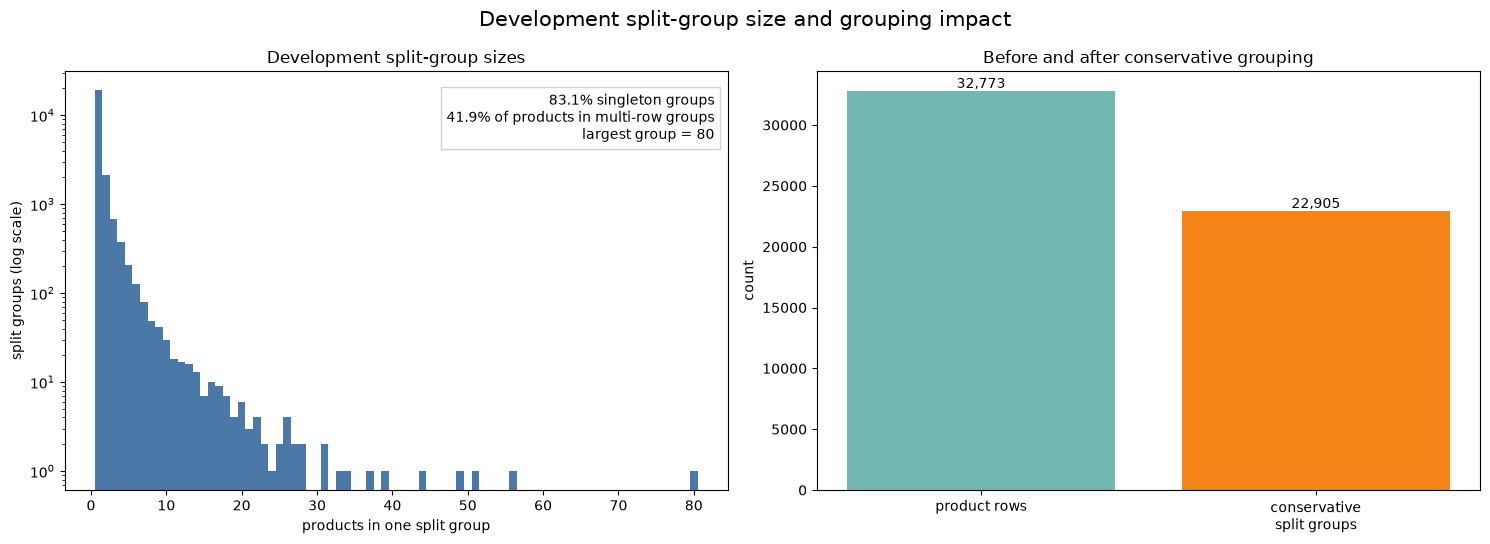

In [16]:
profile = development_family_profile.iloc[0]
figure, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].hist(
    family_sizes["family_size"],
    bins=np.arange(0.5, family_sizes["family_size"].max() + 1.5),
    color="#4C78A8",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("products in one split group")
axes[0].set_ylabel("split groups (log scale)")
axes[0].set_title("Development split-group sizes")
axes[0].text(
    0.98,
    0.95,
    f"{profile['singleton_family_percent']:.1f}% singleton groups\n"
    f"{profile['products_in_multirow_family_percent']:.1f}% of products in multi-row groups\n"
    f"largest group = {int(profile['largest_family_products'])}",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "#cccccc"},
)
group_counts = [profile["product_rows"], profile["conservative_split_groups"]]
axes[1].bar(
    ["product rows", "conservative\nsplit groups"],
    group_counts,
    color=["#72B7B2", "#F58518"],
)
axes[1].set_ylabel("count")
axes[1].set_title("Before and after conservative grouping")
for index, value in enumerate(group_counts):
    axes[1].text(index, value, f"{int(value):,}", ha="center", va="bottom")
figure.suptitle("Development split-group size and grouping impact", fontsize=15)
figure.tight_layout()
_ = save_figure(figure, "family_size_profile.png")
plt.show()


**Finding.** The 32,773 development product rows form 22,905 conservative split groups, a difference of 9,868. This is a count of rows versus groups, not an estimate of the number of independent observations. Broad name groups can contain different designs. Keeping each group in one fold reduces leakage risk without claiming that every group is one verified product or one independent sample.

#### 2.3.4 Evidence that joins products

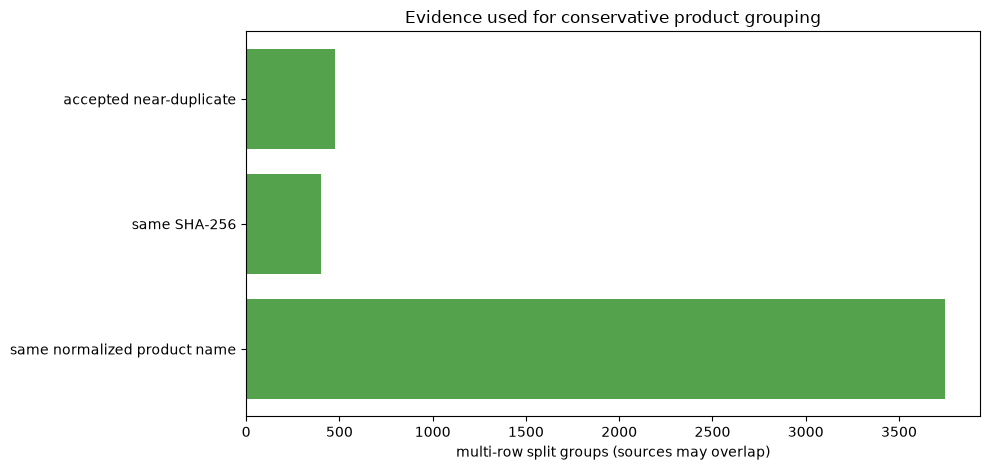

In [17]:
figure, axis = plt.subplots(figsize=(10, 4.8))
axis.barh(
    family_source_profile["family_source"],
    family_source_profile["multirow_families"],
    color="#54A24B",
)
axis.set_xlabel("multi-row split groups (sources may overlap)")
axis.set_title("Evidence used for conservative product grouping")
figure.tight_layout()
_ = save_figure(figure, "family_group_evidence.png")
plt.show()


**Finding.** Normalized names join 3,747 multi-row groups covering 13,485 products, compared with 399 exact-hash groups and 474 accepted near-duplicate groups. The sources can overlap, so these bars describe evidence used for grouping rather than additive totals.

#### 2.3.5 Broad normalized-name groups

In [18]:
BROAD_NAME_GROUP_COUNT = 4
BROAD_NAME_SAMPLE_SIZE = 6
development_family_rows = splits[splits["partition"].eq("development")].copy()
named_development = development_family_rows[
    development_family_rows["product_name_key"].astype(str).ne("")
].copy()

name_group_summary = (
    named_development.groupby("product_name_key", as_index=False)
    .agg(
        group_size=("id", "size"),
        family_count=("product_family_group", "nunique"),
        product_family_group=("product_family_group", "first"),
        family_group_basis=("family_group_basis", "first"),
        display_name=(
            "productDisplayName",
            lambda values: values.astype(str).value_counts().sort_index().idxmax(),
        ),
    )
    .sort_values(["group_size", "product_name_key"], ascending=[False, True])
    .reset_index(drop=True)
)
assert name_group_summary["family_count"].eq(1).all()
selected_name_groups = name_group_summary.head(BROAD_NAME_GROUP_COUNT).copy()
selected_name_groups.insert(
    0, "family_rank", np.arange(1, len(selected_name_groups) + 1)
)
display(
    selected_name_groups[
        [
            "family_rank",
            "display_name",
            "product_family_group",
            "group_size",
            "family_group_basis",
        ]
    ]
)


,family_rank,display_name,product_family_group,group_size,family_group_basis
0,1,Lucera Women Silver Earrings,family_3a8dd25529104cb0,80,normalized_product_name
1,2,Lucera Women Silver Pendant,family_e2fdc52eacb8aa26,56,normalized_product_name
2,3,Lucera Women Silver Ring,family_6d336e886aa8b6eb,49,normalized_product_name
3,4,Catwalk Women Black Heels,family_efc48e17704861aa,44,normalized_product_name


**Finding.** The four broadest development-only name groups contain 80, 56, 49, and 44 products. Their size makes them useful stress tests for the conservative name rule, but a shared name is not proof that every image is the same product design.

#### 2.3.6 Broad-name review index

In [19]:
review_rows = []
selection_rule = (
    "four largest non-empty normalized-name groups; ties by product_name_key; "
    "six evenly spaced positions after numeric ID sort"
)
for group in selected_name_groups.itertuples(index=False):
    members = (
        named_development[
            named_development["product_name_key"].eq(group.product_name_key)
        ]
        .sort_values("id")
        .reset_index(drop=True)
    )
    positions = np.rint(
        np.linspace(0, len(members) - 1, BROAD_NAME_SAMPLE_SIZE)
    ).astype(int)
    assert len(set(positions.tolist())) == BROAD_NAME_SAMPLE_SIZE
    for sample_rank, position in enumerate(positions, start=1):
        member = members.iloc[position]
        review_rows.append(
            {
                "selection_rule": selection_rule,
                "family_rank": int(group.family_rank),
                "sample_rank": sample_rank,
                "sorted_member_position": int(position + 1),
                "id": int(member["id"]),
                "path": str(member["path"]),
                "sha256": str(member["sha256"]),
                "productDisplayName": str(member["productDisplayName"]),
                "product_name_key": str(member["product_name_key"]),
                "product_family_group": str(member["product_family_group"]),
                "group_size": int(group.group_size),
                "family_group_basis": str(member["family_group_basis"]),
            }
        )
broad_name_review = pd.DataFrame(review_rows)
_ = write_table(broad_name_review, "broad_name_family_review_index.csv")


Wrote results/evidence/data_preparation/broad_name_family_review_index.csv | rows=24 | sha256=fa2a6a2646a7923383b9a19eb641ac2b0881c58c8b78306084c8f1768017d3d8


**Finding.** The review index records six evenly spaced sorted IDs from each of the four broad groups, giving 24 fixed examples. This makes the contact sheet repeatable and avoids choosing only images that support a preferred conclusion.

#### 2.3.7 Broad-name contact sheet

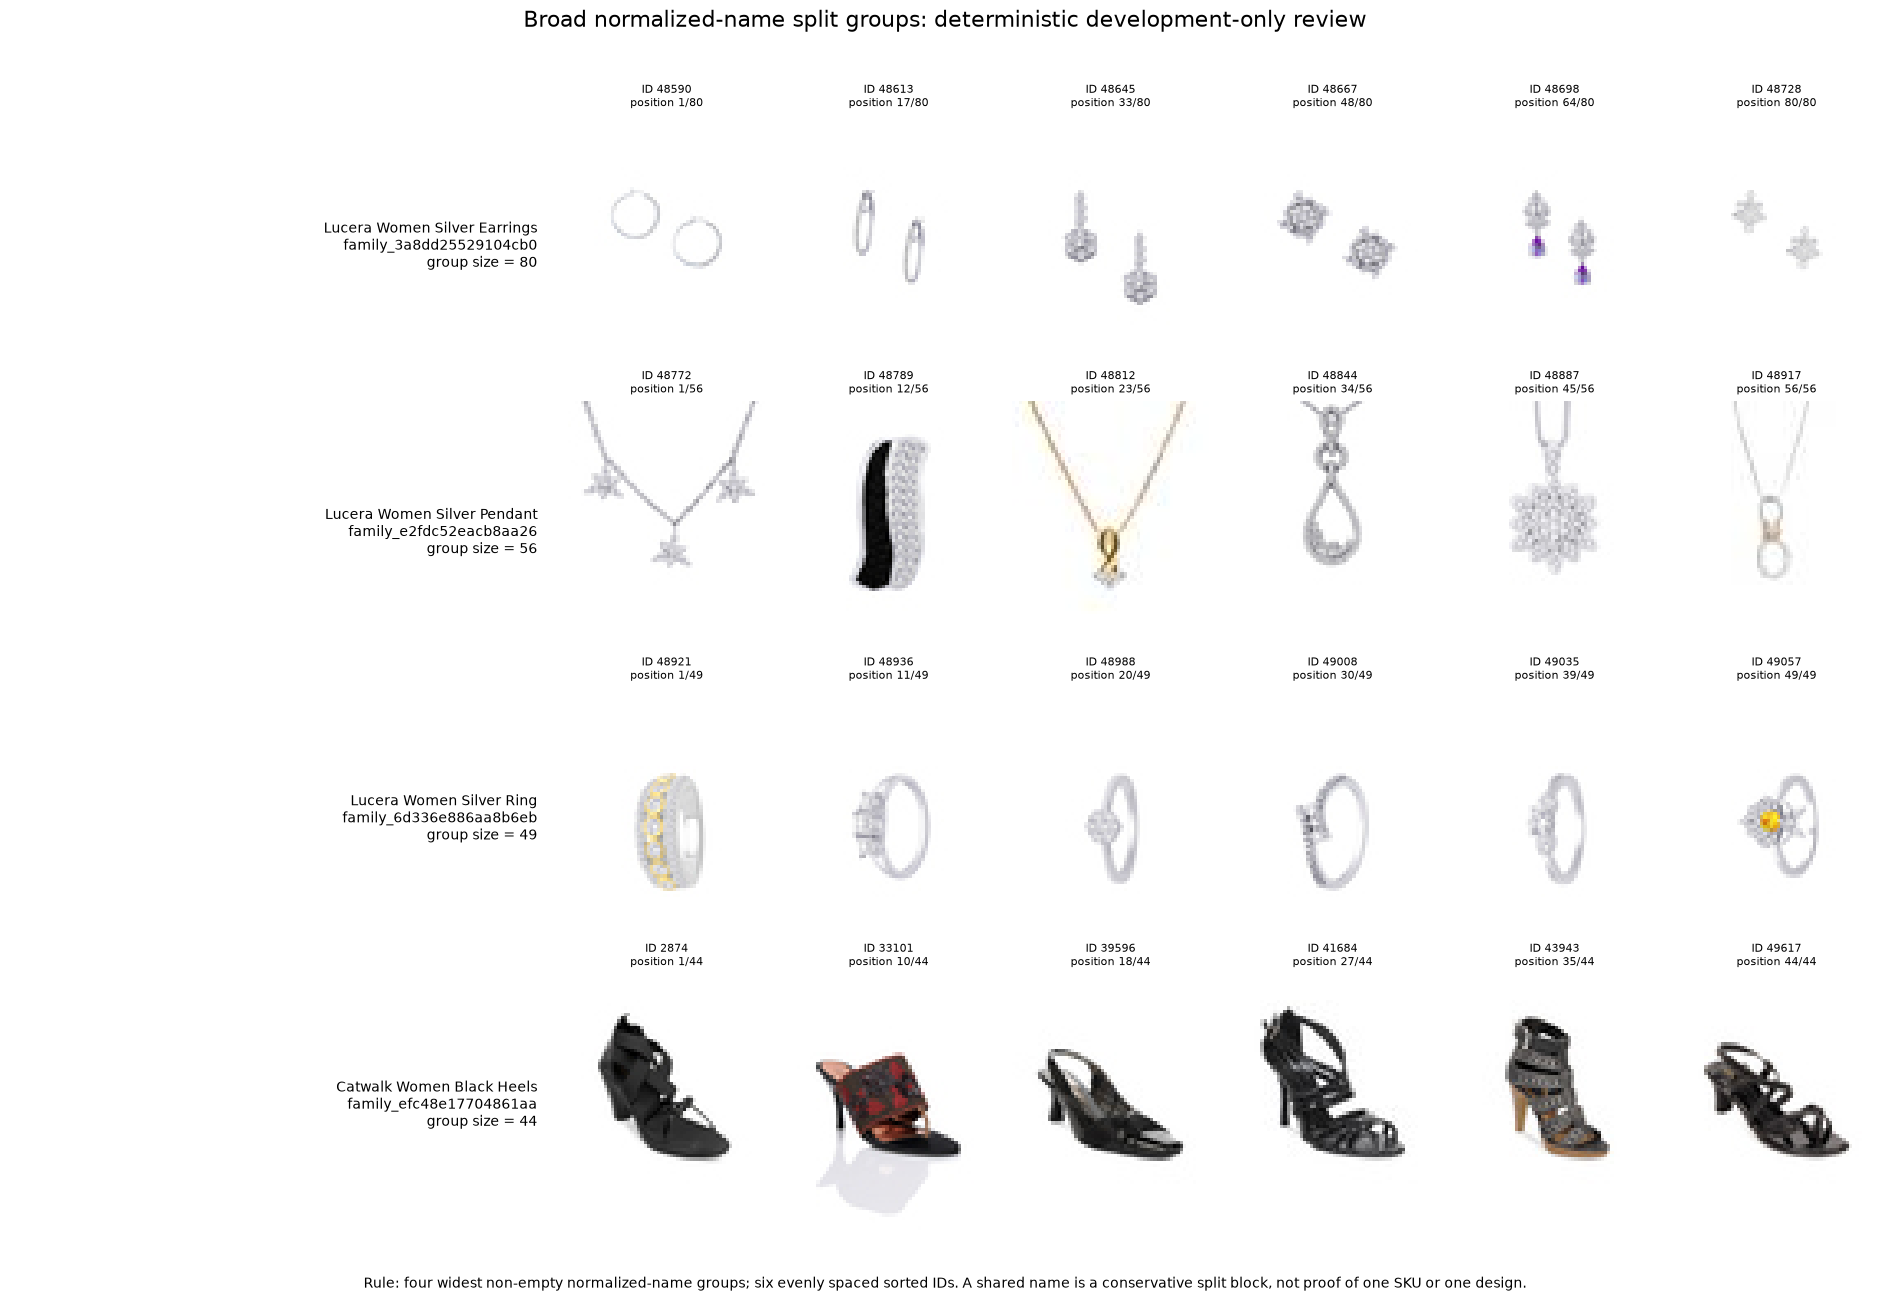

In [20]:
figure, axes = plt.subplots(
    BROAD_NAME_GROUP_COUNT,
    BROAD_NAME_SAMPLE_SIZE + 1,
    figsize=(19, 13),
    gridspec_kw={"width_ratios": [2.6, *([1] * BROAD_NAME_SAMPLE_SIZE)]},
)
for row_index, group in enumerate(selected_name_groups.itertuples(index=False)):
    label_axis = axes[row_index, 0]
    label_axis.text(
        0.98,
        0.5,
        f"{group.display_name}\n{group.product_family_group}\n"
        f"group size = {int(group.group_size)}",
        ha="right",
        va="center",
        fontsize=10,
        wrap=True,
    )
    label_axis.axis("off")
    samples = broad_name_review[broad_name_review["family_rank"].eq(group.family_rank)]
    for column_index, sample in enumerate(samples.itertuples(index=False), start=1):
        axis = axes[row_index, column_index]
        with Image.open(ROOT / sample.path) as source:
            axis.imshow(source.convert("RGB"))
        axis.set_title(
            f"ID {sample.id}\nposition {sample.sorted_member_position}/{sample.group_size}",
            fontsize=8,
        )
        axis.axis("off")
figure.suptitle(
    "Broad normalized-name split groups: deterministic development-only review",
    fontsize=16,
    y=0.995,
)
figure.text(
    0.5,
    0.012,
    "Rule: four widest non-empty normalized-name groups; six evenly spaced sorted IDs. "
    "A shared name is a conservative split block, not proof of one SKU or one design.",
    ha="center",
    fontsize=10,
)
figure.tight_layout(rect=[0, 0.04, 1, 0.97])
figure_record = save_figure(figure, "broad_name_family_review.png")
plt.show()


**Finding.** The sheet shows the 24 fixed examples side by side; the 80-row silver-earring group visibly contains several designs. The name rule is therefore suitable as a safe split block, but not as verified SKU or real-product ground truth.

#### 2.3.8 Group boundary audit

In [21]:
def group_crossings(frame: pd.DataFrame, group_column: str) -> tuple[int, int, int]:
    usable = frame[frame[group_column].astype(str).ne("")].copy()
    active = usable[~usable["partition"].eq("quarantine")]
    active_partition_crossings = active.groupby(group_column)["partition"].nunique().gt(1).sum()
    development = usable[usable["partition"].eq("development")]
    fold_crossings = development.groupby(group_column)["cv_fold"].nunique().gt(1).sum()
    group_partitions = usable.groupby(group_column)["partition"].agg(set)
    quarantine_links = group_partitions.map(
        lambda values: "quarantine" in values and len(values - {"quarantine"}) > 0
    ).sum()
    return int(active_partition_crossings), int(fold_crossings), int(quarantine_links)


boundary_rows = []
for relationship in ("sha256", "duplicate_group", "product_family_group", "product_name_key"):
    partition_crossings, fold_crossings, quarantine_links = group_crossings(splits, relationship)
    boundary_rows.append(
        (relationship, "group", partition_crossings, fold_crossings, quarantine_links)
    )

"definition-only: structural group crossing checks are ready"

accepted = near_candidates[
    near_candidates["accepted_near_duplicate"].astype(str).str.lower().eq("true")
][["id_1", "id_2"]].copy()
allocation = splits.set_index("id")[["partition", "cv_fold"]]
near_partition_crossings = 0
near_fold_crossings = 0
near_quarantine_links = 0
for pair in accepted.itertuples(index=False):
    if pair.id_1 not in allocation.index or pair.id_2 not in allocation.index:
        continue
    left = allocation.loc[pair.id_1]
    right = allocation.loc[pair.id_2]
    touches_quarantine = "quarantine" in {left["partition"], right["partition"]}
    near_quarantine_links += int(touches_quarantine and left["partition"] != right["partition"])
    if not touches_quarantine:
        near_partition_crossings += int(left["partition"] != right["partition"])
    if left["partition"] == right["partition"] == "development":
        near_fold_crossings += int(left["cv_fold"] != right["cv_fold"])
boundary_rows.append(
    (
        "accepted_perceptual_pair",
        "pair",
        near_partition_crossings,
        near_fold_crossings,
        near_quarantine_links,
    )
)


group_boundary_audit = pd.DataFrame(
    boundary_rows,
    columns=[
        "relationship",
        "quarantine_relationship_unit",
        "active_partition_crossings",
        "development_fold_crossings",
        "relationships_to_quarantine",
    ],
)
display(group_boundary_audit)
assert (
    group_boundary_audit[["active_partition_crossings", "development_fold_crossings"]]
    .to_numpy()
    .sum()
    == 0
)
_ = write_table(group_boundary_audit, "group_boundary_audit.csv")


,relationship,quarantine_relationship_unit,active_partition_crossings,development_fold_crossings,relationships_to_quarantine
0,sha256,group,0,0,0
1,duplicate_group,group,0,0,0
2,product_family_group,group,0,0,0
3,product_name_key,group,0,0,13
4,accepted_perceptual_pair,pair,0,0,6


Wrote results/evidence/data_preparation/group_boundary_audit.csv | rows=5 | sha256=5a4f2eaebead8643d75e99ee6d4fa45a31f24739960edf84233ac2e43cf5c613


**Finding.** Exact hashes, duplicate groups, family groups, normalized names, and accepted perceptual pairs all have zero active partition and development-fold crossings. Thirteen name links and six accepted pairs touch quarantine, but none bridges two active evaluation groups.

#### 2.3.9 Cross-role perceptual scope

In [22]:
accepted_cross_role = near_candidates[
    near_candidates["accepted_near_duplicate"].astype(str).str.lower().eq("true")
    & near_candidates["cross_role"].astype(str).str.lower().eq("true")
]
labelled_cross_role_ids = set(
    accepted_cross_role.loc[accepted_cross_role["role_1"].eq("labelled"), "id_1"].astype(int)
) | set(accepted_cross_role.loc[accepted_cross_role["role_2"].eq("labelled"), "id_2"].astype(int))
cross_role_component = (
    splits["is_cross_role_exact_duplicate"] | splits["is_cross_role_near_duplicate"]
)
cross_role_component_ids = set(splits.loc[cross_role_component, "id"].astype(int))
transitive_cross_role_ids = cross_role_component_ids - labelled_cross_role_ids
cross_role_component_not_quarantined = int(
    (~splits.loc[cross_role_component, "partition"].eq("quarantine")).sum()
)


perceptual_scope_audit = pd.DataFrame(
    [
        ("accepted candidate pairs", len(accepted)),
        ("accepted pairs linking active data to quarantine", near_quarantine_links),
        ("direct cross-role labelled endpoints", len(labelled_cross_role_ids)),
        ("full cross-role component labelled products", len(cross_role_component_ids)),
        ("transitive cross-role component products", len(transitive_cross_role_ids)),
        ("cross-role component products outside quarantine", cross_role_component_not_quarantined),
    ],
    columns=["fact", "count"],
)
display(perceptual_scope_audit)
assert cross_role_component_not_quarantined == 0
_ = write_table(perceptual_scope_audit, "perceptual_scope_audit.csv")


,fact,count
0,accepted candidate pairs,2080
1,accepted pairs linking active data to quarantine,6
2,direct cross-role labelled endpoints,19
3,full cross-role component labelled products,20
4,transitive cross-role component products,1
5,cross-role component products outside quarantine,0


Wrote results/evidence/data_preparation/perceptual_scope_audit.csv | rows=6 | sha256=ea3c6ca25f1e7bfae66f9f2c4d2452778000c189debda83b73cb3ce48fbbe532


**Finding.** Nineteen direct cross-role labelled endpoints expand to 20 products after one transitive family link is included. All 20 stay inside quarantine, so visually related teacher-train and prediction products cannot leak across the active boundary.

#### 2.3.10 Near-threshold pair table

In [23]:
development_ids = set(splits.loc[splits["partition"].eq("development"), "id"].astype(int))
review_candidates = near_candidates[
    near_candidates["role_1"].eq("labelled")
    & near_candidates["role_2"].eq("labelled")
    & near_candidates["id_1"].astype(int).isin(development_ids)
    & near_candidates["id_2"].astype(int).isin(development_ids)
]
threshold_review = near_threshold_review(review_candidates, accepted_pairs=3, rejected_pairs=3)
display(
    threshold_review[
        [
            "id_1",
            "id_2",
            "review_side",
            "signed_rule_margin",
            "boundary_distance",
            "accepted_near_duplicate",
            "pipeline_effect",
        ]
    ].round(4)
)


,id_1,id_2,review_side,signed_rule_margin,boundary_distance,accepted_near_duplicate,pipeline_effect
2,15412,15418,accepted side,0.0000,0.0000,True,none; evidence-only sample
0,49116,49133,accepted side,0.0000,0.0000,True,none; evidence-only sample
1,49118,49133,accepted side,0.0000,0.0000,True,none; evidence-only sample
3,49159,49161,rejected side,-0.0191,0.0191,False,none; evidence-only sample
4,49093,49135,rejected side,-0.0316,0.0316,False,none; evidence-only sample
5,47568,47569,rejected side,-0.0321,0.0321,False,none; evidence-only sample


**Finding.** The fixed review takes the three closest accepted pairs and three closest rejected pairs from development. Accepted margins are exactly at the rule boundary, while rejected distances range from 0.0191 to 0.0321; none changes the pipeline.

#### 2.3.11 Near-threshold image review

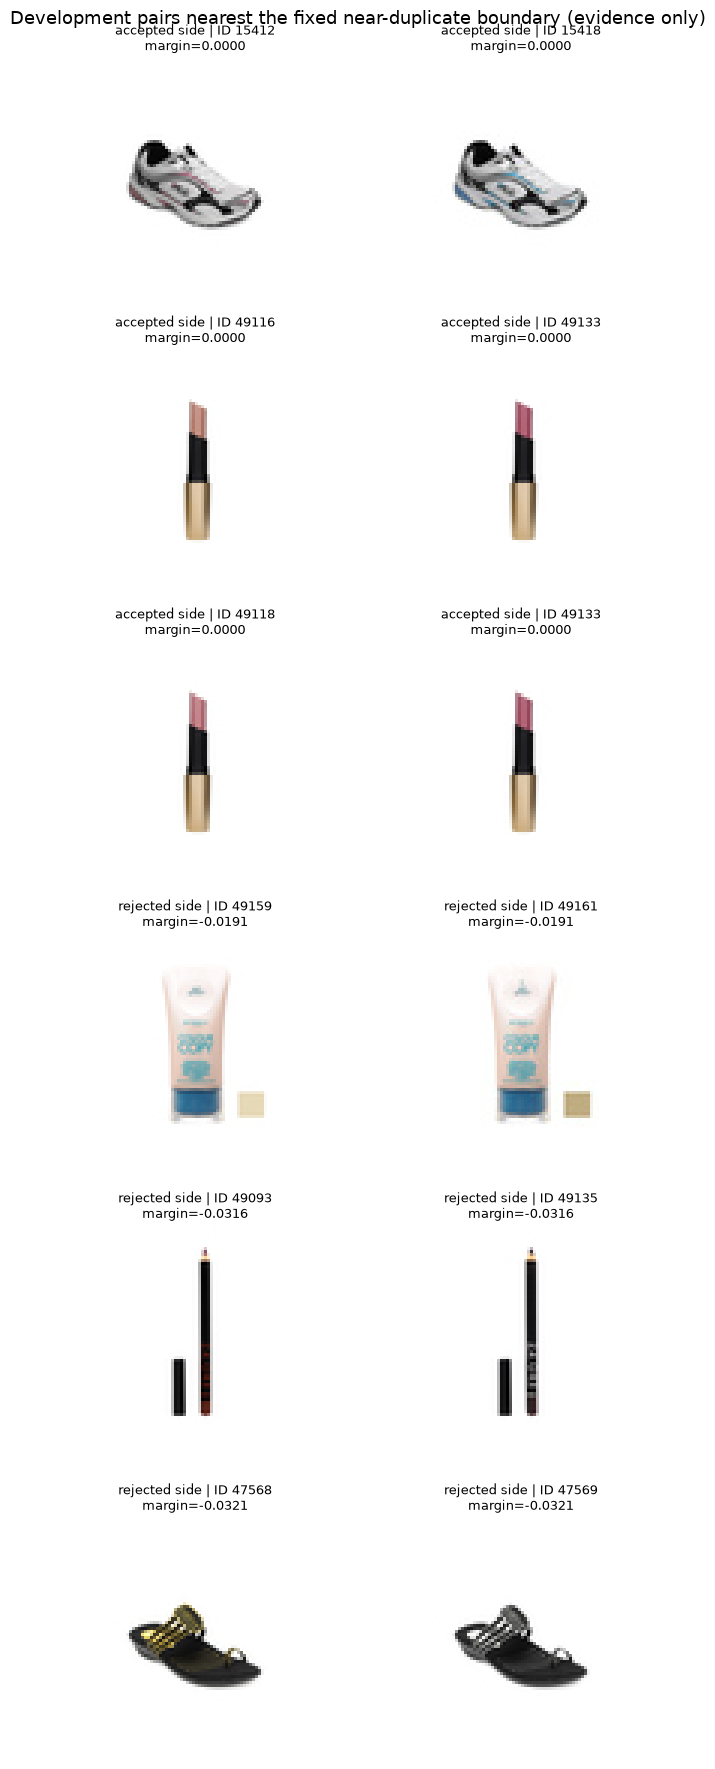

In [24]:
path_by_id = splits.set_index("id")["path"]
figure, axes = plt.subplots(len(threshold_review), 2, figsize=(8, 3 * len(threshold_review)))
for row_index, row in enumerate(threshold_review.itertuples(index=False)):
    for column_index, item_id in enumerate((int(row.id_1), int(row.id_2))):
        axis = axes[row_index, column_index]
        with Image.open(ROOT / str(path_by_id.loc[item_id])) as source:
            axis.imshow(source.convert("RGB"))
        axis.set_title(
            f"{row.review_side} | ID {item_id}\nmargin={row.signed_rule_margin:.4f}",
            fontsize=9,
        )
        axis.axis("off")
figure.suptitle(
    "Development pairs nearest the fixed near-duplicate boundary (evidence only)",
    fontsize=13,
)
figure.tight_layout()
figure_record = save_figure(figure, "near_duplicate_threshold_review.png")
plt.show()


**Finding.** Twelve images show the six boundary pairs in the same order as the saved table, making visual similarity directly reviewable. The sheet checks whether the fixed rule looks reasonable; it does not relabel pairs or feed a judgement back into the split.

## 3. Leakage-safe data preparation

**Purpose.** Verify the one protected partition and five saved development folds
after duplicate and product-family relationships have been established.


### 3.1 Development, internal holdout, quarantine, and five CV folds

**Purpose.** Verify the single split and explain the practical ratio. The old train
and validation IDs form `development`; the existing holdout and quarantine IDs are
unchanged.

**Outside helper used here.** `src/fashion/data/splits.py` provides
`cv_assignment_digest()` for the frozen development ID/fold hash.


#### 3.1.1 Frozen partition membership

In [25]:
EXPECTED_DIGESTS = {
    "development": "2639d731f89942fd9598f9552bb092dd634830c3e6a63d0b569cfc2aa4362d01",
    "holdout": "48a9e2e389657744d2771a3ab5ca34e85e015b21b18ef4d0ed29c2e648cf8fc0",
    "quarantine": "5a672e34e485c8ddad0cef37c2dc37d99f8774f8874279a5d0ed69aff7022f43",
}
EXPECTED_CV_DIGEST = "bad7bc4ae65fbbfd815567f4ccfa308d6e57dc650bc15c0b8e798867a335f2fd"


def id_set_digest(values: pd.Series) -> str:
    payload = "".join(f"{value}\n" for value in sorted(values.astype(int).tolist()))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


partition_summary = (
    splits["partition"].value_counts().rename_axis("partition").reset_index(name="products")
)
partition_summary["percent_of_image_backed"] = partition_summary["products"] / len(splits) * 100
partition_summary["id_set_sha256"] = partition_summary["partition"].map(
    lambda partition: id_set_digest(splits.loc[splits["partition"].eq(partition), "id"])
)
display(partition_summary)
assert (
    dict(zip(partition_summary["partition"], partition_summary["id_set_sha256"]))
    == EXPECTED_DIGESTS
)
current_cv_digest = cv_assignment_digest(splits)
print(f"Development ID/fold SHA-256: {current_cv_digest}")
assert current_cv_digest == EXPECTED_CV_DIGEST
_ = write_table(partition_summary, "partition_summary.csv")


,partition,products,percent_of_image_backed,id_set_sha256
0,development,32773,84.877758,2639d731f89942fd9598f9552bb092dd634830c3e6a63d0b569cfc2aa4362d01
1,holdout,5778,14.964260,48a9e2e389657744d2771a3ab5ca34e85e015b21b18ef4d0ed29c2e648cf8fc0
2,quarantine,61,0.157982,5a672e34e485c8ddad0cef37c2dc37d99f8774f8874279a5d0ed69aff7022f43


Development ID/fold SHA-256: bad7bc4ae65fbbfd815567f4ccfa308d6e57dc650bc15c0b8e798867a335f2fd
Wrote results/evidence/data_preparation/partition_summary.csv | rows=3 | sha256=86006f4bd3c047af2f3c1947bcaa643f5af93919245b38ce03d75f941f1d3199


**Finding.** The frozen contract contains 32,773 development, 5,778 holdout, and 61 quarantine products, and every sorted-ID digest matches. The CV digest also matches the one documented refreeze, proving that this run did not resample membership or fold assignments.

**Outside helper used here.** `src/fashion/data/dataset.py` provides `iter_cv_folds()`,
which yields each training/validation view from the canonical `cv_fold` column.


#### 3.1.2 Five-fold balance

In [26]:
cv_rows = []
for fold, training, validation in iter_cv_folds(splits):
    cv_rows.append(
        {
            "validation_fold": fold,
            "training_products": len(training),
            "validation_products": len(validation),
            "holdout_products": int(splits["partition"].eq("holdout").sum()),
            "training_percent_all_image_backed": len(training) / len(splits) * 100,
            "validation_percent_all_image_backed": len(validation) / len(splits) * 100,
            "holdout_percent_all_image_backed": splits["partition"].eq("holdout").mean() * 100,
            "training_families": training["product_family_group"].nunique(),
            "validation_families": validation["product_family_group"].nunique(),
        }
    )
cv_balance = pd.DataFrame(cv_rows)
display(cv_balance.round(2))
development_for_cv = splits[splits["partition"].eq("development")]
fold_sizes = development_for_cv["cv_fold"].value_counts().sort_index()
largest_development_family = int(development_for_cv.groupby("product_family_group").size().max())
fold_size_range = int(fold_sizes.max() - fold_sizes.min())
print(f"Fold size range={fold_size_range}; largest development family={largest_development_family}")
assert fold_size_range <= largest_development_family
_ = write_table(cv_balance, "cv_fold_balance.csv")


,validation_fold,training_products,validation_products,holdout_products,training_percent_all_image_backed,validation_percent_all_image_backed,holdout_percent_all_image_backed,training_families,validation_families
0,0,26220,6553,5778,67.91,16.97,14.96,18341,4564
1,1,26217,6556,5778,67.90,16.98,14.96,18312,4593
2,2,26220,6553,5778,67.91,16.97,14.96,18328,4577
3,3,26219,6554,5778,67.90,16.97,14.96,18304,4601
4,4,26216,6557,5778,67.90,16.98,14.96,18335,4570


Fold size range=4; largest development family=80
Wrote results/evidence/data_preparation/cv_fold_balance.csv | rows=5 | sha256=cf66895d27369d423cc0815ae7afd52b2e5687ad740d5c0ac0208463d50beb0e


**Finding.** Each CV view has 26,216-26,220 training products and 6,553-6,557 validation products, while all 5,778 holdout products remain untouched. A four-product fold-size range is very small given the largest family has 80 products, but the evaluation policy must still be chosen before experiments.

## 4. Development-only exploratory data analysis and hypotheses

**Purpose.** Explore labels, group support, shortcut risks, image properties,
and transform risks using development data only, then turn those observations
into questions that later task notebooks must test.


### 4.1 Development-only target analysis

**Purpose.** Describe label availability and class shape using development only.
`development` includes the old train and validation rows. Holdout and quarantine
labels are absent from every calculation below.


#### 4.1.1 Target coverage

In [27]:
development = splits[splits["partition"].eq("development")].copy()
target_rows = []
for target in TARGETS:
    valid = development[f"has_{target}_label"]
    counts = development.loc[valid, target].astype(str).value_counts()
    target_rows.append(
        {
            "target": target,
            "development_products": len(development),
            "labelled_products": int(valid.sum()),
            "missing_products": int((~valid).sum()),
            "classes": int(counts.size),
            "largest_class_products": int(counts.max()),
            "smallest_class_products": int(counts.min()),
            "largest_to_smallest_ratio": float(counts.max() / counts.min()),
        }
    )
target_summary = pd.DataFrame(target_rows)
display(target_summary.round(2))
_ = write_table(target_summary, "target_summary.csv")
print(
    "Literal 'NA' usage rows with a true mask:",
    int((development["usage"].eq("NA") & development["has_usage_label"]).sum()),
)


,target,development_products,labelled_products,missing_products,classes,largest_class_products,smallest_class_products,largest_to_smallest_ratio
0,articleType,32773,32773,0,124,5748,1,5748.00
1,season,32773,32753,20,4,16235,1329,12.22
2,gender,32773,32773,0,5,17753,543,32.69
3,usage,32773,32772,1,9,25151,1,25151.00


Wrote results/evidence/data_preparation/target_summary.csv | rows=4 | sha256=32bb9d9caac86a939d5cd341135a087953f63fcef394c9deecd8b9203070e8cf
Literal 'NA' usage rows with a true mask: 61


**Finding.** Development contains 124 article types, 4 seasons, 5 genders, and 9 usage labels; only 20 Season and 1 Usage values are blank. ArticleType and Usage are most imbalanced, with largest-to-smallest class ratios of 5,748:1 and 25,151:1.

#### 4.1.2 Missing labels and repaired names

In [28]:
raw_metadata = pd.read_csv(train_csv, keep_default_na=False)
spill_columns = [column for column in raw_metadata if column.startswith("Unnamed:")]
raw_spill_mask = (
    raw_metadata[spill_columns]
    .astype(str)
    .apply(lambda column: column.str.strip().ne(""))
    .any(axis=1)
)
season_missing = development[~development["has_season_label"]].copy()
usage_missing = development[~development["has_usage_label"]].copy()
repaired_development = development["product_name_repaired"].astype(str).str.lower().eq("true")
repaired_image_backed = splits["product_name_repaired"].astype(str).str.lower().eq("true")
raw_missing_name = (
    raw_metadata["productDisplayName"].astype(str).str.strip().str.casefold().eq("na")
)
metadata_pattern_audit = pd.DataFrame(
    [
        (
            "missing season rows",
            len(season_missing),
            "; ".join(
                [
                    f"articleType={','.join(sorted(season_missing['articleType'].unique()))}",
                    f"usage={','.join(sorted(season_missing['usage'].unique()))}",
                    f"year={','.join(map(str, sorted(season_missing['year'].unique())))}",
                    f"ID range={season_missing['id'].min()}-{season_missing['id'].max()}",
                ]
            ),
        ),
        (
            "missing usage rows",
            len(usage_missing),
            "; ".join(
                f"ID {int(row.id)} productDisplayName={row.productDisplayName}"
                for row in usage_missing.itertuples(index=False)
            ),
        ),
        ("raw rows with product-name spill", int(raw_spill_mask.sum()), "repair all name segments"),
        (
            "image-backed rows with repaired name",
            int(repaired_image_backed.sum()),
            f"{int(repaired_development.sum())} are in development",
        ),
        (
            "raw literal NA product names",
            int(raw_missing_name.sum()),
            "missing for product-name repair and family grouping only",
        ),
        (
            "development literal NA usage labels",
            int((development["usage"].eq("NA") & development["has_usage_label"]).sum()),
            "valid teacher vocabulary label",
        ),
    ],
    columns=["fact", "rows", "evidence_or_policy"],
)
display(metadata_pattern_audit)


,fact,rows,evidence_or_policy
0,missing season rows,20,articleType=Sports Shoes; usage=Sports; year=2011; ID range=5354-5407
1,missing usage rows,1,ID 28319 productDisplayName=RTV_LoadTest
2,raw rows with product-name spill,21,repair all name segments
3,image-backed rows with repaired name,21,16 are in development
4,raw literal NA product names,7,missing for product-name repair and family grouping only
5,development literal NA usage labels,61,valid teacher vocabulary label


**Finding.** The audit separates 20 missing Season labels, one missing Usage label, and 21 repaired product-name spills instead of treating them as one problem. Seven literal `NA` product names are missing for grouping, while 61 literal `NA` Usage values remain valid labels.

#### 4.1.3 Target long tails

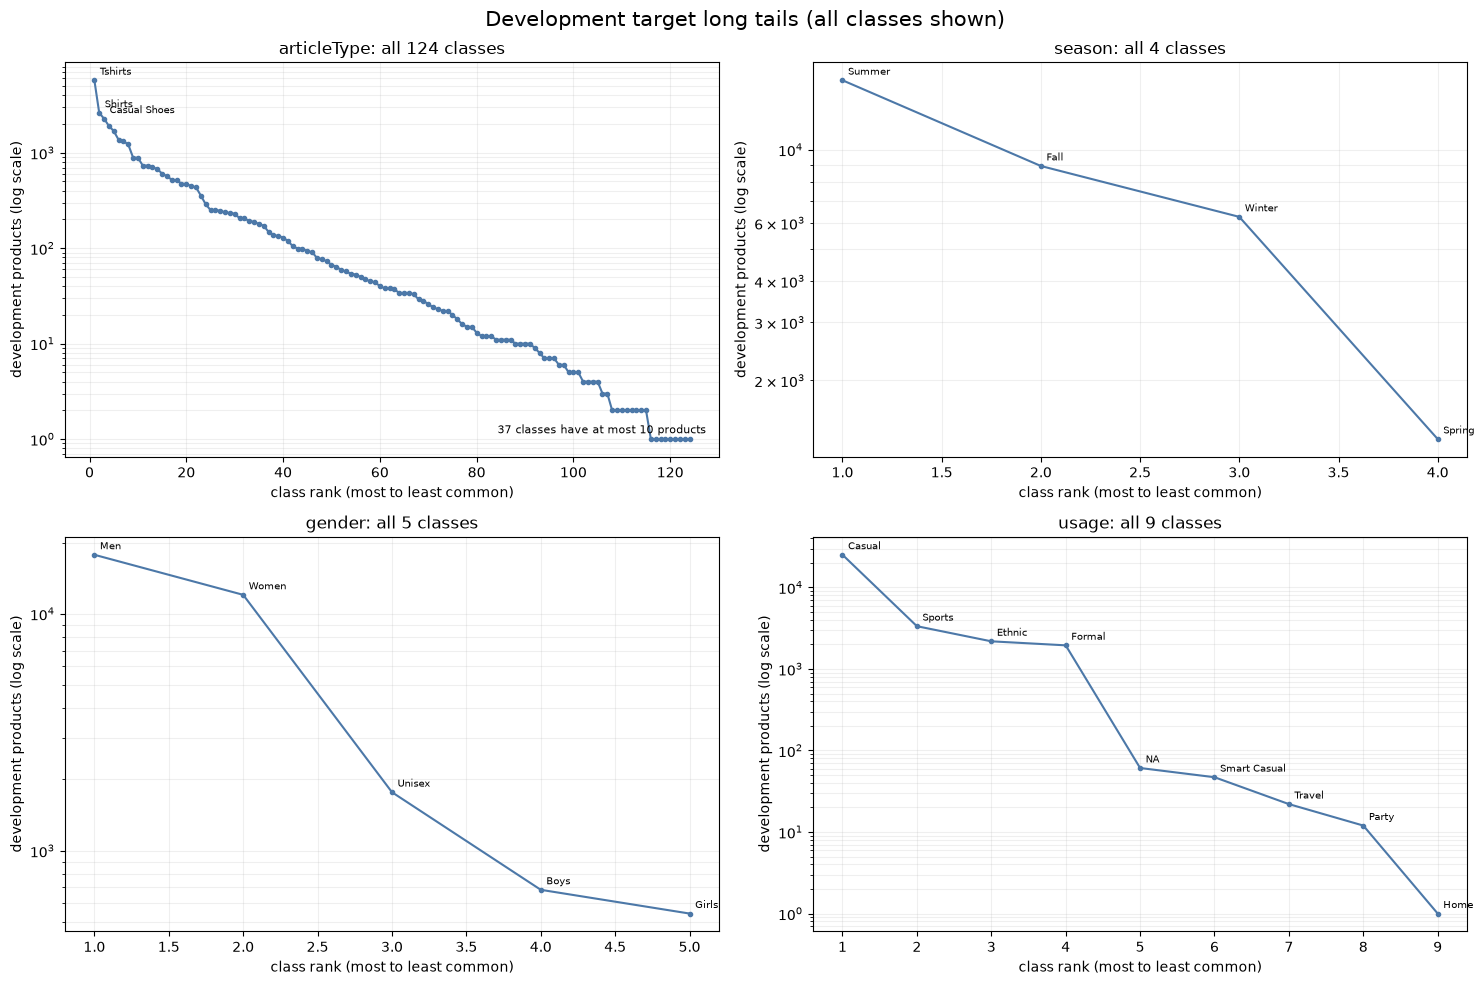

In [29]:
figure, axes = plt.subplots(2, 2, figsize=(15, 10))
for axis, target in zip(axes.ravel(), TARGETS):
    valid = development[f"has_{target}_label"]
    counts = development.loc[valid, target].astype(str).value_counts().sort_values(ascending=False)
    ranks = np.arange(1, len(counts) + 1)
    axis.plot(ranks, counts.to_numpy(), marker="o", markersize=3, color="#4C78A8")
    axis.set_yscale("log")
    axis.set_title(f"{target}: all {len(counts)} classes")
    axis.set_xlabel("class rank (most to least common)")
    axis.set_ylabel("development products (log scale)")
    axis.grid(alpha=0.2, which="both")
    if target == "usage":
        annotation_indexes = list(range(len(counts)))
    elif len(counts) > 20:
        annotation_indexes = list(range(min(3, len(counts))))
    else:
        annotation_indexes = sorted(
            set(range(min(3, len(counts)))) | set(range(max(0, len(counts) - 3), len(counts)))
        )
    for index in annotation_indexes:
        axis.annotate(
            str(counts.index[index]),
            (ranks[index], counts.iloc[index]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=7,
        )
    if len(counts) > 20:
        axis.text(
            0.98,
            0.06,
            f"{int(counts.le(10).sum())} classes have at most 10 products",
            transform=axis.transAxes,
            ha="right",
            fontsize=8,
        )
figure.suptitle("Development target long tails (all classes shown)", fontsize=15)
figure.tight_layout()
figure_record = save_figure(figure, "target_distributions.png")
plt.show()


**Finding.** ArticleType and Usage extend from one-product classes to classes with 5,748 and 25,151 products, so a linear chart would hide the rare tail. The log scale exposes that tail; it describes the data but does not choose a loss, sampler, or metric.

### 4.2 Imbalance and class support by fold

**Purpose.** Show whether each development label is available in each fold and in
the corresponding four-fold training portion. No class is removed merely for being
rare.

**Outside helper used here.** `src/fashion/data/evidence.py` provides
`fold_support_tables()` for the scatter points, validation counts, and zero-training
flags plotted below.


#### 4.2.1 Rare-class warnings

In [30]:
class_summary_path = ROOT / "data/processed/development_class_summary.csv"
class_summary = pd.read_csv(class_summary_path, keep_default_na=False)
rare_classes = class_summary[
    class_summary["rare_warning"].astype(str).ne("")
    | pd.to_numeric(class_summary["untrainable_fold_count"], errors="coerce").gt(0)
].copy()
imbalance_handoff = class_summary.groupby("target", as_index=False).agg(
    classes=("class", "size"),
    classes_in_all_folds=("fold_count", lambda values: pd.to_numeric(values).eq(5).sum()),
    classes_with_warning=("rare_warning", lambda values: values.astype(str).ne("").sum()),
    classes_untrainable_in_any_fold=(
        "untrainable_fold_count",
        lambda values: pd.to_numeric(values).gt(0).sum(),
    ),
    minimum_class_products=(
        "development_product_count",
        lambda values: pd.to_numeric(values).min(),
    ),
)
display(imbalance_handoff)
display(
    rare_classes[
        [
            "target",
            "class",
            "development_product_count",
            "development_family_count",
            "folds_present",
            "minimum_fold_training_products",
            "untrainable_fold_count",
            "rare_warning",
        ]
    ].head(30)
)
class_summary_digest = sha256_file(class_summary_path)
print(f"Read {relative(class_summary_path)} | rows={len(class_summary):,}")
print(f"SHA-256: {class_summary_digest}")
_ = write_table(imbalance_handoff, "imbalance_handoff.csv")


,target,classes,classes_in_all_folds,classes_with_warning,classes_untrainable_in_any_fold,minimum_class_products
0,articleType,124,98,26,12,1
1,gender,5,5,0,0,543
2,season,4,4,0,0,1329
3,usage,9,8,1,1,1


,target,class,development_product_count,development_family_count,folds_present,minimum_fold_training_products,untrainable_fold_count,rare_warning
1,articleType,Baby Dolls,2,2,"1,2",1,0,low_independent_family_support
7,articleType,Body Wash and Scrub,1,1,1,0,1,untrainable_in_one_or_more_folds
20,articleType,Compact,4,1,2,0,1,untrainable_in_one_or_more_folds
21,articleType,Concealer,2,1,4,0,1,untrainable_in_one_or_more_folds
23,articleType,Cushion Covers,1,1,4,0,1,untrainable_in_one_or_more_folds
29,articleType,Eyeshadow,4,3,"0,2,4",2,0,low_independent_family_support
39,articleType,Hat,2,2,"1,2",1,0,low_independent_family_support
42,articleType,Highlighter and Blush,4,1,3,0,1,untrainable_in_one_or_more_folds
44,articleType,Ipad,1,1,1,0,1,untrainable_in_one_or_more_folds
51,articleType,Key chain,1,1,3,0,1,untrainable_in_one_or_more_folds


Read data/processed/development_class_summary.csv | rows=142
SHA-256: e45cb3e5c093dc0fea8f68da11779e607f34a3c037f719fbc0c67a63899c7af0
Wrote results/evidence/data_preparation/imbalance_handoff.csv | rows=4 | sha256=480b00f4d2c8cd39d4a44241645d67ed00b52bde9bcb05f1b9193c444fc262b5


**Finding.** Warnings affect 26 of 124 ArticleType classes and 1 of 9 Usage classes, while Season and Gender have none. The notebook shows a short handoff view, but the complete 142-row class table remains saved for later metric and sampling decisions.

#### 4.2.2 Zero-training fold cases

In [31]:
support_source = (
    class_summary.assign(_untrainable=pd.to_numeric(class_summary["untrainable_fold_count"]).gt(0))
    .sort_values(
        ["_untrainable", "target", "development_product_count", "class"],
        ascending=[False, True, True, True],
    )
    .drop(columns="_untrainable")
)
support_points, rare_fold_counts, untrainable_flags = fold_support_tables(support_source)

untrainable_by_target = (
    support_points.assign(
        is_untrainable=pd.to_numeric(support_points["untrainable_fold_count"]).gt(0)
    )
    .groupby("target", as_index=False)["is_untrainable"]
    .sum()
)
display(untrainable_by_target)
display(
    support_points.loc[
        pd.to_numeric(support_points["untrainable_fold_count"]).gt(0),
        ["target", "class", "development_product_count", "development_family_count"],
    ]
)


,target,is_untrainable
0,articleType,12
1,gender,0
2,season,0
3,usage,1


,target,class,development_product_count,development_family_count
7,articleType,Body Wash and Scrub,1,1
23,articleType,Cushion Covers,1,1
44,articleType,Ipad,1,1
51,articleType,Key chain,1,1
64,articleType,Lounge Tshirts,1,1
76,articleType,Rain Jacket,1,1
77,articleType,Rain Trousers,1,1
90,articleType,Shoe Laces,1,1
106,articleType,Ties and Cufflinks,1,1
21,articleType,Concealer,2,1


**Finding.** Twelve ArticleType classes and the one-product Usage class `Home` have at least one fold with validation examples but zero training examples. Those fold scores cannot show learned class performance, so later reports must state how such cases enter macro metrics.

#### 4.2.3 Products versus split groups

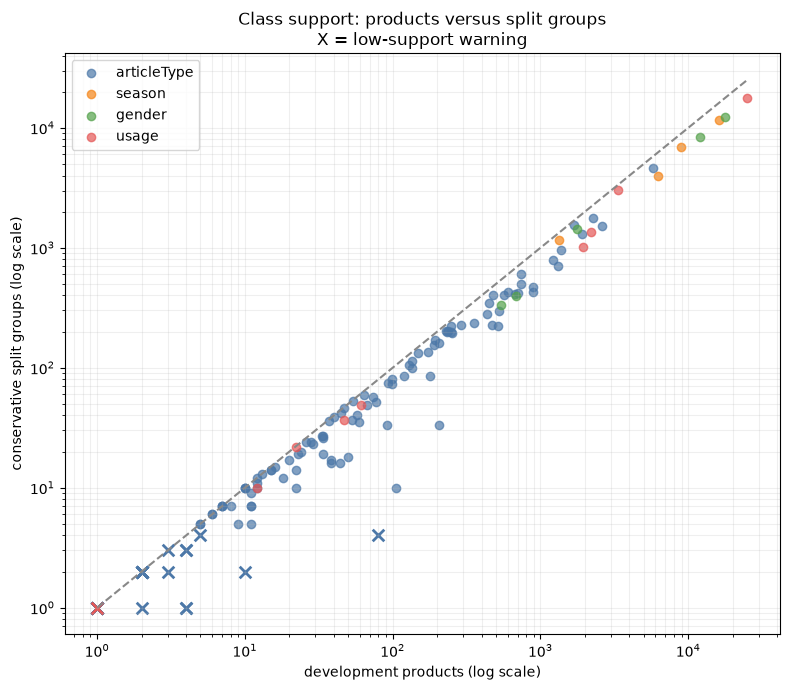

In [32]:
figure, axis = plt.subplots(figsize=(8, 7))
target_colors = dict(zip(TARGETS, ["#4C78A8", "#F58518", "#54A24B", "#E45756"]))
for target in TARGETS:
    rows = support_points[support_points["target"].eq(target)]
    warning = rows["rare_warning"].astype(str).ne("")
    axis.scatter(
        rows.loc[~warning, "development_product_count"],
        rows.loc[~warning, "development_family_count"],
        label=target,
        alpha=0.7,
        color=target_colors[target],
    )
    axis.scatter(
        rows.loc[warning, "development_product_count"],
        rows.loc[warning, "development_family_count"],
        marker="x",
        s=70,
        linewidth=2,
        color=target_colors[target],
    )
support_limit = max(
    support_points["development_product_count"].max(),
    support_points["development_family_count"].max(),
)
axis.plot([1, support_limit], [1, support_limit], linestyle="--", color="#888888")
axis.set_xscale("log")
axis.set_yscale("log")
axis.set_xlabel("development products (log scale)")
axis.set_ylabel("conservative split groups (log scale)")
axis.set_title("Class support: products versus split groups\nX = low-support warning")
axis.legend()
axis.grid(alpha=0.2, which="both")
figure.tight_layout()
_ = save_figure(figure, "class_support_products_vs_groups.png")
plt.show()


**Finding.** Most classes sit near the equal-count line, but related products can make product counts look larger than their independent split-group support. The crosses identify low-support warnings, making group count the safer guide for fold reliability.

#### 4.2.4 Rare-class fold support

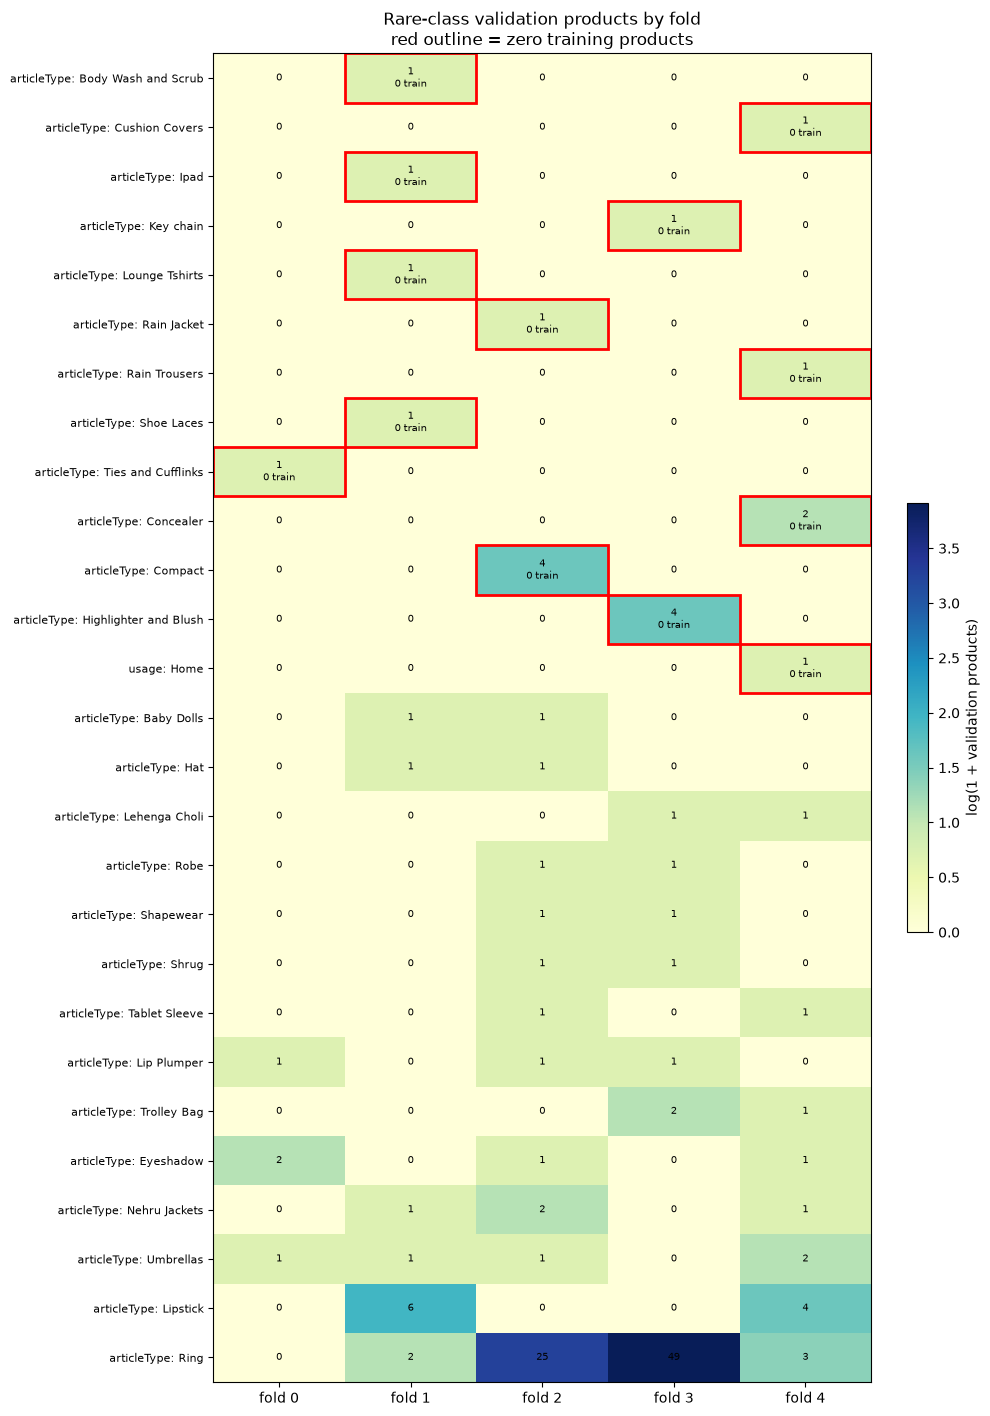

In [33]:
figure_height = max(10, 4 + 0.38 * len(rare_fold_counts))
figure, axis = plt.subplots(figsize=(10, figure_height))
heat_values = np.log1p(rare_fold_counts.to_numpy(dtype=float))
heatmap = axis.imshow(heat_values, aspect="auto", cmap="YlGnBu")
axis.set_xticks(range(rare_fold_counts.shape[1]), rare_fold_counts.columns)
axis.set_yticks(range(rare_fold_counts.shape[0]), rare_fold_counts.index, fontsize=8)
axis.set_title("Rare-class validation products by fold\nred outline = zero training products")
for row_index in range(rare_fold_counts.shape[0]):
    for column_index in range(rare_fold_counts.shape[1]):
        count = int(rare_fold_counts.iloc[row_index, column_index])
        is_untrainable = bool(untrainable_flags.iloc[row_index, column_index])
        label = f"{count}\n0 train" if is_untrainable else str(count)
        axis.text(column_index, row_index, label, ha="center", va="center", fontsize=7)
        if is_untrainable:
            axis.add_patch(
                plt.Rectangle(
                    (column_index - 0.5, row_index - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor="red",
                    linewidth=2,
                )
            )
figure.colorbar(heatmap, ax=axis, fraction=0.03, label="log(1 + validation products)")
figure.tight_layout()
_ = save_figure(figure, "rare_class_fold_support.png")
plt.show()


**Finding.** The fold map shows exactly where each rare class appears in validation and outlines cells whose matching training side has zero products. Keeping this separate from the scatter makes the failure pattern readable and prevents a single total from hiding fold-specific gaps.

### 4.3 Shortcut risks and categorical association

**Purpose.** Look for two development-only warning signals: other targets that can
be guessed from `articleType`, and Season patterns aligned with year or file size.
These are descriptive shortcut checks, not model scores. Association does not prove
that one field causes another.

Normalized mutual information (NMI) is bounded from 0 to 1: 0 means almost no
association and 1 means perfect association. There is no universal "good" or "bad"
cutoff; each value must be read against the variables, sample, and task.

#### 4.3.1 NMI definition

In [34]:
def normalized_mutual_information(left: pd.Series, right: pd.Series) -> float:
    table = pd.crosstab(left.astype(str), right.astype(str)).to_numpy(dtype=float)
    probability = table / table.sum()
    left_probability = probability.sum(axis=1, keepdims=True)
    right_probability = probability.sum(axis=0, keepdims=True)
    expected = left_probability @ right_probability
    positive = probability > 0
    mutual_information = np.sum(
        probability[positive] * np.log(probability[positive] / expected[positive])
    )
    left_entropy = -np.sum(
        left_probability[left_probability > 0] * np.log(left_probability[left_probability > 0])
    )
    right_entropy = -np.sum(
        right_probability[right_probability > 0] * np.log(right_probability[right_probability > 0])
    )
    denominator = (left_entropy + right_entropy) / 2
    return float(mutual_information / denominator) if denominator else 0.0


"definition-only: normalized_mutual_information for categorical development labels"


'definition-only: normalized_mutual_information for categorical development labels'

**Definition only.** NMI measures symmetric association on complete development rows from 0 (almost none) to 1 (perfect), with no universal good/bad cutoff. It complements the later majority benchmark but is not model accuracy, causal evidence, or a feature-selection rule.

**Outside helper used in the next cell.** `src/fashion/data/evidence.py` provides
`shortcut_benchmarks()` and `article_target_heatmap()`; the NMI helper itself remains
visible in the notebook cell above.

#### 4.3.2 NMI values

In [35]:
nmi = pd.DataFrame(np.eye(len(TARGETS)), index=TARGETS, columns=TARGETS, dtype=float)
nmi_sample_sizes = []
for left, right in combinations(TARGETS, 2):
    valid = development[f"has_{left}_label"] & development[f"has_{right}_label"]
    score = normalized_mutual_information(
        development.loc[valid, left], development.loc[valid, right]
    )
    nmi.loc[left, right] = nmi.loc[right, left] = score
    nmi_sample_sizes.append(
        {"target_1": left, "target_2": right, "n": int(valid.sum()), "nmi": score}
    )
nmi_long = pd.DataFrame(nmi_sample_sizes)
display(nmi.round(3))
_ = write_table(nmi_long, "joint_target_nmi.csv")
largest_nmi = nmi_long.loc[nmi_long["nmi"].idxmax()]
display(
    pd.DataFrame(
        [
            {
                "largest_off_diagonal_pair": (
                    f"{largest_nmi['target_1']} - {largest_nmi['target_2']}"
                ),
                "n": int(largest_nmi["n"]),
                "nmi": float(largest_nmi["nmi"]),
                "scale_note": "0=no association; 1=perfect; no universal cutoff",
            }
        ]
    ).round(3)
)


,articleType,season,gender,usage
articleType,1.000,0.174,0.194,0.254
season,0.174,1.000,0.024,0.038
gender,0.194,0.024,1.000,0.104
usage,0.254,0.038,0.104,1.000


Wrote results/evidence/data_preparation/joint_target_nmi.csv | rows=6 | sha256=4187ef751040b3fa38ddf6f4cb6dd3425318a09ebe499d5e5c879a3e76cc2631


,largest_off_diagonal_pair,n,nmi,scale_note
0,articleType - usage,32772,0.254,0=no association; 1=perfect; no universal cutoff


**Finding.** The strongest off-diagonal relationship is ArticleType-Usage at 0.254 across 32,772 complete rows; Season-Gender is weakest at 0.024. All six exact pair values and sample sizes stay in CSV, so the rounded matrix does not become the only evidence.

#### 4.3.3 NMI heatmap

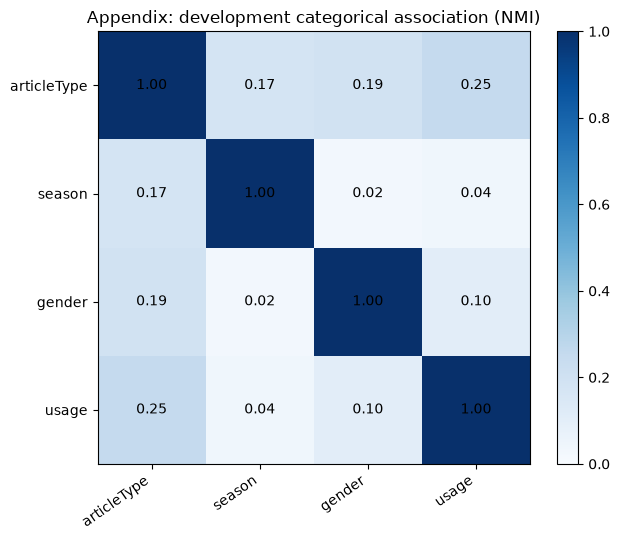

In [36]:
figure, axis = plt.subplots(figsize=(6.5, 5.5))
image = axis.imshow(nmi.to_numpy(), vmin=0, vmax=1, cmap="Blues")
axis.set_xticks(range(len(TARGETS)), TARGETS, rotation=35, ha="right")
axis.set_yticks(range(len(TARGETS)), TARGETS)
for row in range(len(TARGETS)):
    for column in range(len(TARGETS)):
        axis.text(column, row, f"{nmi.iloc[row, column]:.2f}", ha="center", va="center")
axis.set_title("Appendix: development categorical association (NMI)")
figure.colorbar(image, ax=axis, fraction=0.046)
figure.tight_layout()
figure_record = save_figure(figure, "joint_target_nmi.png")
plt.show()


**Finding.** Every off-diagonal value is at most 0.254, so the development targets share some structure without being interchangeable. The common 0-to-1 colour scale makes pairs comparable, but the pattern remains descriptive rather than causal.

#### 4.3.4 ArticleType shortcut benchmark

In [37]:
shortcut_summary = shortcut_benchmarks(development)
display(shortcut_summary.round(4))
shortcut_tables = {
    target: article_target_heatmap(development, target, top_article_types=30)
    for target in ("season", "usage", "gender")
}


,grouping_target,predicted_target,complete_development_rows,global_majority_label,global_majority_accuracy,group_majority_accuracy,association_lift_percentage_points,interpretation
0,articleType,season,32753,Summer,0.4957,0.6505,15.4795,descriptive association/shortcut risk; not model accuracy or causality
1,articleType,usage,32772,Casual,0.7675,0.9004,13.2979,descriptive association/shortcut risk; not model accuracy or causality
2,articleType,gender,32773,Men,0.5417,0.7854,24.3737,descriptive association/shortcut risk; not model accuracy or causality


**Finding.** ArticleType-majority agreement rises from 49.6% to 65.0% for Season, 76.7% to 90.0% for Usage, and 54.2% to 78.5% for Gender. These 13.3-24.4 point lifts warn that a model could exploit label associations; they are not image-model scores.

#### 4.3.5 ArticleType shortcut heatmaps

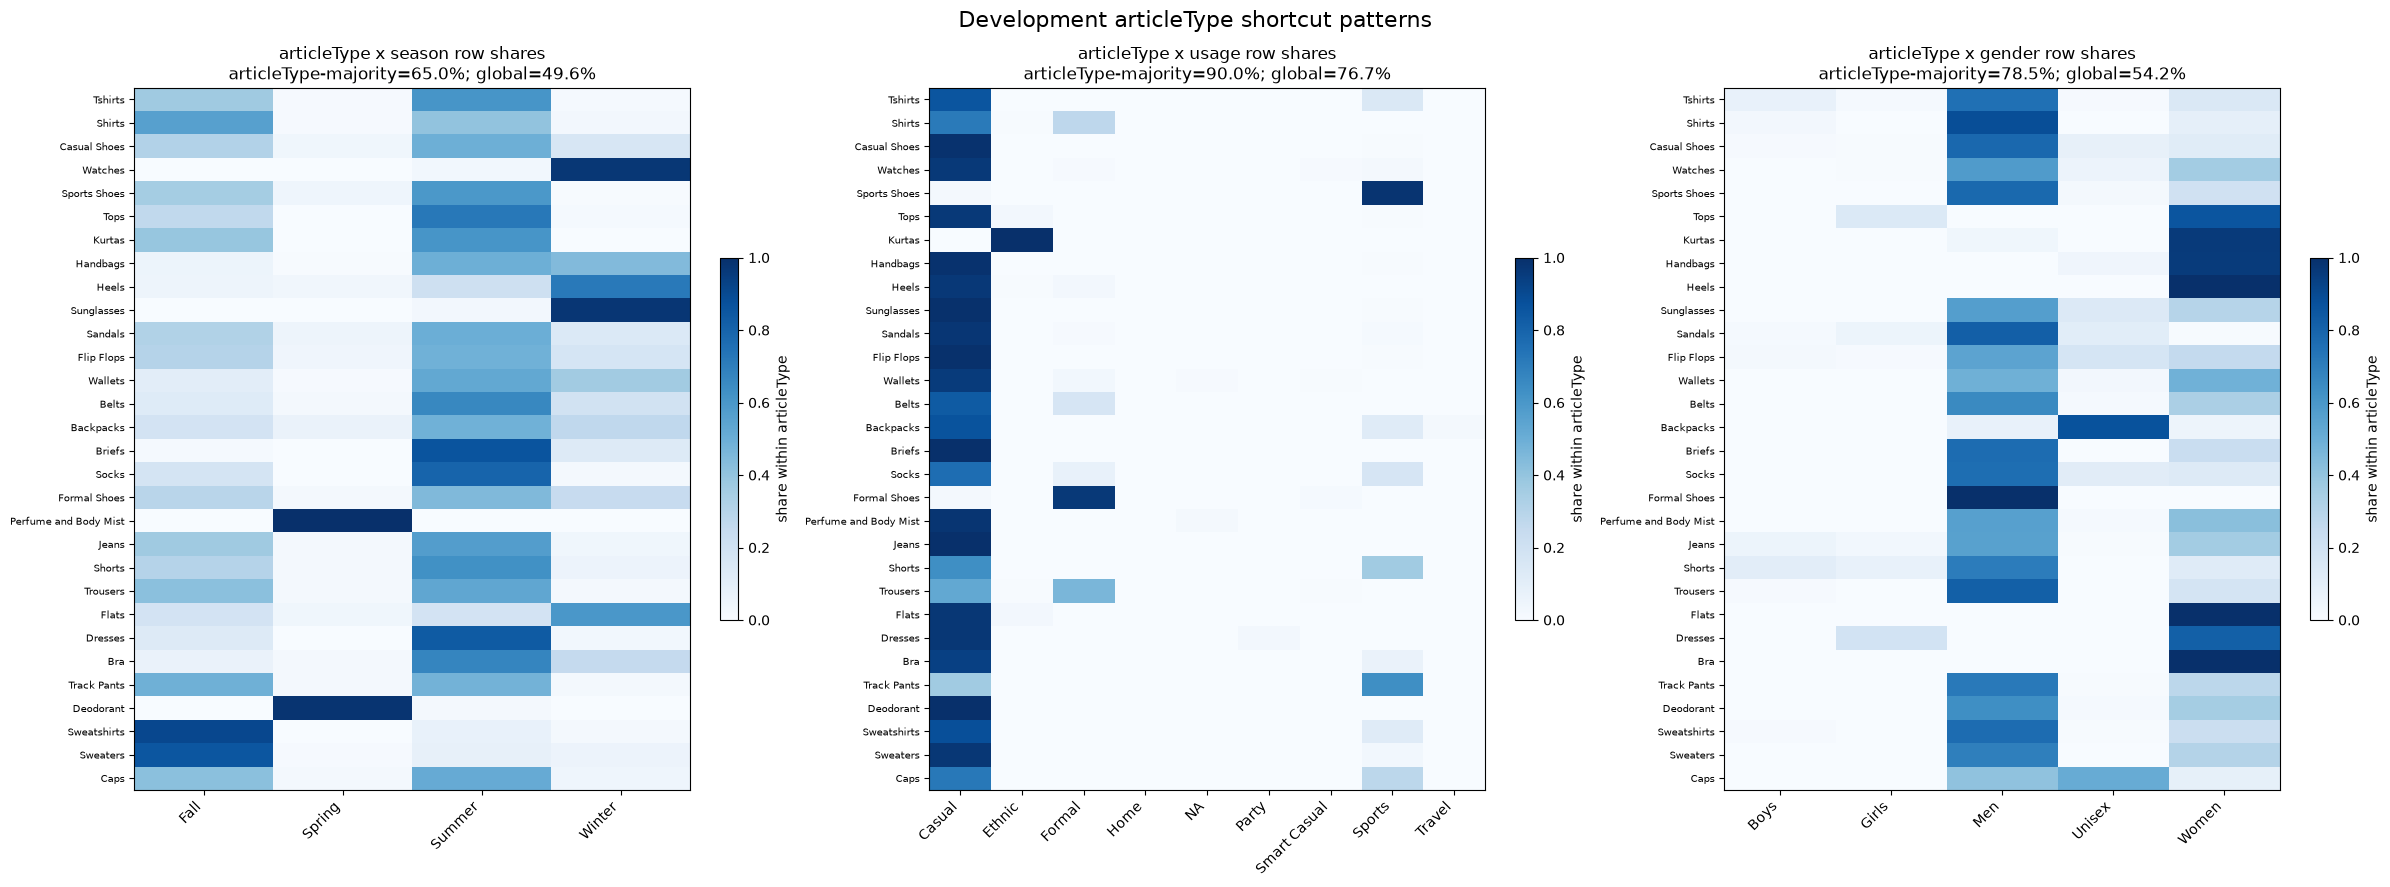

In [38]:
figure, axes = plt.subplots(1, 3, figsize=(24, 9))
benchmark_lookup = shortcut_summary.set_index("predicted_target")
for axis, target in zip(axes, ("season", "usage", "gender")):
    table = shortcut_tables[target]
    image = axis.imshow(table.to_numpy(), vmin=0, vmax=1, aspect="auto", cmap="Blues")
    axis.set_xticks(range(table.shape[1]), table.columns, rotation=45, ha="right")
    axis.set_yticks(range(table.shape[0]), table.index, fontsize=7)
    row = benchmark_lookup.loc[target]
    axis.set_title(
        f"articleType x {target} row shares\n"
        f"articleType-majority={row['group_majority_accuracy']:.1%}; "
        f"global={row['global_majority_accuracy']:.1%}"
    )
    figure.colorbar(image, ax=axis, fraction=0.03, label="share within articleType")
figure.suptitle("Development articleType shortcut patterns", fontsize=16)
figure.tight_layout()
_ = save_figure(figure, "shortcut_risk_heatmaps.png")
plt.show()


**Finding.** The three panels compare the same 30 common ArticleType rows against Season, Usage, and Gender, so shared dark bands are easy to spot. Strong row concentrations show where a task model may lean on catalogue structure instead of the intended visual evidence.

#### 4.3.6 Shortcut-majority benchmark

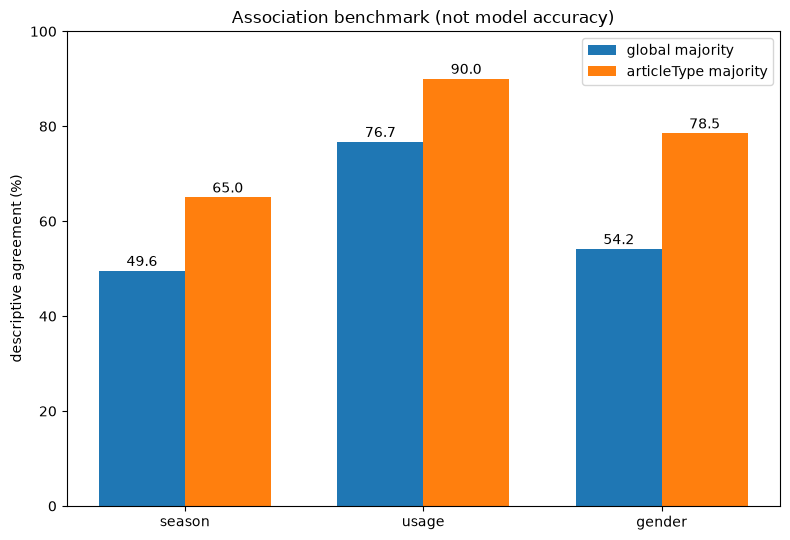

In [39]:
figure, axis = plt.subplots(figsize=(8, 5.5))
positions = np.arange(len(shortcut_summary))
width = 0.36
global_values = shortcut_summary["global_majority_accuracy"].to_numpy() * 100
group_values = shortcut_summary["group_majority_accuracy"].to_numpy() * 100
axis.bar(positions - width / 2, global_values, width, label="global majority")
axis.bar(positions + width / 2, group_values, width, label="articleType majority")
axis.set_xticks(positions, shortcut_summary["predicted_target"])
axis.set_ylabel("descriptive agreement (%)")
axis.set_ylim(0, 100)
axis.set_title("Association benchmark (not model accuracy)")
axis.legend()
for index, value in enumerate(global_values):
    axis.text(index - width / 2, value + 1, f"{value:.1f}", ha="center")
for index, value in enumerate(group_values):
    axis.text(index + width / 2, value + 1, f"{value:.1f}", ha="center")
figure.tight_layout()
_ = save_figure(figure, "shortcut_majority_benchmark.png")
plt.show()


**Finding.** Every ArticleType lookup beats its global-majority baseline, with the largest lift for Gender at 24.4 percentage points. The separate bar chart makes the size of that shortcut risk clear without shrinking the more detailed heatmaps.

#### 4.3.7 Season acquisition measures

In [40]:
season_development = development[development["has_season_label"]].copy()
season_development["year"] = pd.to_numeric(
    season_development["year"], errors="raise"
).astype(int)
season_development["file_size_bytes"] = pd.to_numeric(
    season_development["file_size_bytes"], errors="raise"
)
year_counts = (
    season_development.groupby("year").size().rename("image_count").reset_index()
)
season_by_year = pd.crosstab(
    season_development["year"], season_development["season"], normalize="index"
)

def stable_majority(values: pd.Series) -> str:
    counts = values.astype(str).value_counts().sort_index()
    return str(counts.idxmax())


global_season = stable_majority(season_development["season"])
global_majority_agreement = float(
    season_development["season"].eq(global_season).mean()
)
year_modes = season_development.groupby("year")["season"].agg(stable_majority)
year_predictions = season_development["year"].map(year_modes)
year_majority_agreement = float(
    year_predictions.eq(season_development["season"]).mean()
)
rows_2011_2012 = int(season_development["year"].isin([2011, 2012]).sum())
share_2011_2012 = rows_2011_2012 / len(season_development)

"definition-only: development-only year and Season measures are ready"


'definition-only: development-only year and Season measures are ready'

**Definition only.** These measures use only development rows with a valid Season and derive year counts, within-year Season shares, stable majority labels, and compressed file sizes. They describe same-row acquisition patterns and never read the holdout or evaluate a model.

#### 4.3.8 Acquisition summary

In [41]:
season_medians = season_development.groupby("season").agg(
    rows=("id", "size"), median_file_size_bytes=("file_size_bytes", "median")
)
season_medians["median_file_size_kib"] = (
    season_medians["median_file_size_bytes"] / 1024
)

acquisition_summary_rows = [
    {
        "metric": "development rows with valid Season",
        "group": "all",
        "n": len(season_development),
        "value": float(len(season_development)),
        "unit": "rows",
        "note": "development only; holdout and quarantine excluded",
    },
    {
        "metric": "year concentration",
        "group": "2011-2012",
        "n": len(season_development),
        "value": share_2011_2012,
        "unit": "share",
        "note": f"{rows_2011_2012} rows",
    },
    {
        "metric": "global majority agreement",
        "group": global_season,
        "n": len(season_development),
        "value": global_majority_agreement,
        "unit": "agreement share",
        "note": "descriptive baseline; not model accuracy",
    },
    {
        "metric": "year-majority agreement",
        "group": "year",
        "n": len(season_development),
        "value": year_majority_agreement,
        "unit": "agreement share",
        "note": "same-row descriptive lookup; not model evaluation",
    },
]
for season_name, row in season_medians.sort_index().iterrows():
    acquisition_summary_rows.append(
        {
            "metric": "median file size",
            "group": str(season_name),
            "n": int(row["rows"]),
            "value": float(row["median_file_size_kib"]),
            "unit": "KiB",
            "note": "1 KiB = 1024 bytes",
        }
    )
acquisition_summary = pd.DataFrame(acquisition_summary_rows)
display(acquisition_summary.round(4))
_ = write_table(acquisition_summary, "acquisition_shortcut_summary.csv")


,metric,group,n,value,unit,note
0,development rows with valid Season,all,32753,32753.0000,rows,development only; holdout and quarantine excluded
1,year concentration,2011-2012,32753,0.6991,share,22896 rows
2,global majority agreement,Summer,32753,0.4957,agreement share,descriptive baseline; not model accuracy
3,year-majority agreement,year,32753,0.7446,agreement share,same-row descriptive lookup; not model evaluation
4,median file size,Fall,8928,2.1748,KiB,1 KiB = 1024 bytes
5,median file size,Spring,1329,17.7412,KiB,1 KiB = 1024 bytes
6,median file size,Summer,16235,14.9941,KiB,1 KiB = 1024 bytes
7,median file size,Winter,6261,18.0537,KiB,1 KiB = 1024 bytes


Wrote results/evidence/data_preparation/acquisition_shortcut_summary.csv | rows=8 | sha256=f0e2cba33acb6af543781a715bb10834ed68e31331fdb4635cf39dbf73ba376e


**Finding.** Of 32,753 valid-Season rows, 22,896 (69.9%) come from 2011-2012; a year lookup agrees 74.5% of the time versus 49.6% for the global majority. Fall's 2.2 KiB median file is also far below the 15.0-18.1 KiB medians for other seasons.

#### 4.3.9 Year concentration and Season mix

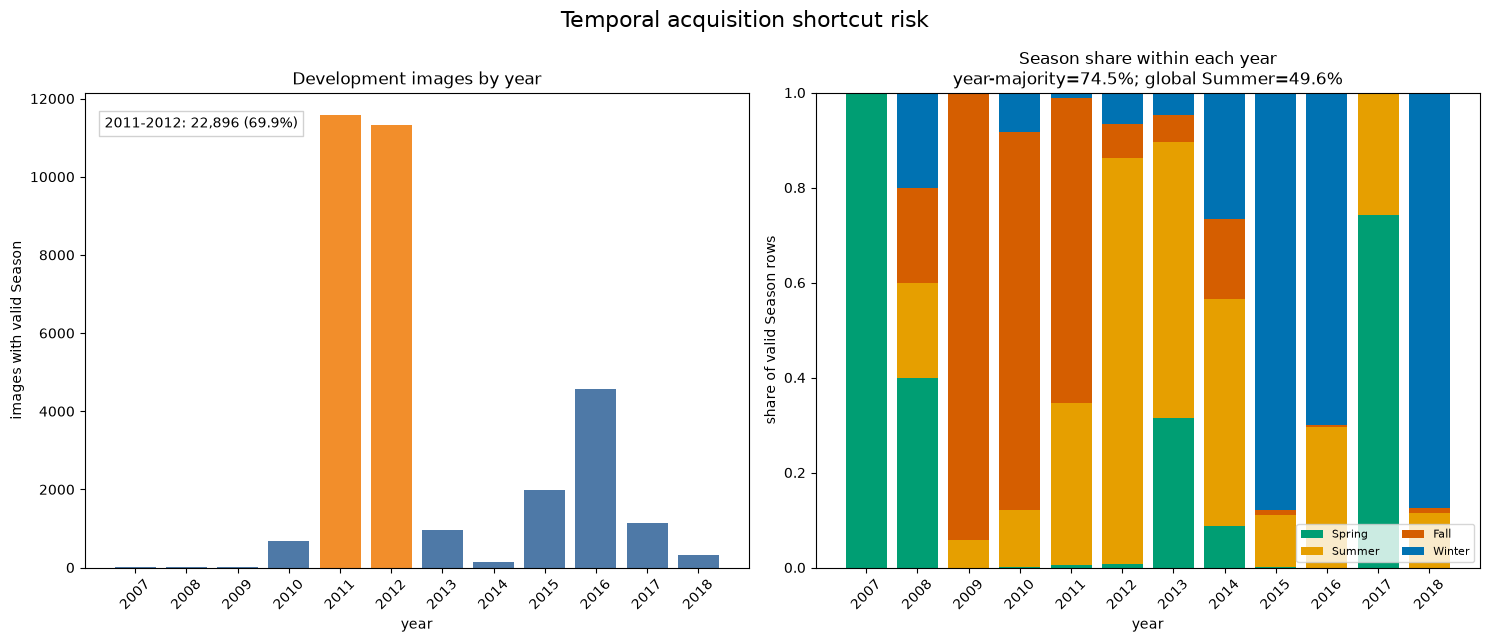

In [42]:
year_values = year_counts["year"].to_numpy()
season_colors = {
    "Fall": "#D55E00",
    "Spring": "#009E73",
    "Summer": "#E69F00",
    "Winter": "#0072B2",
}
figure, axes = plt.subplots(1, 2, figsize=(15, 6.5))
count_colors = [
    "#F28E2B" if year in {2011, 2012} else "#4E79A7" for year in year_values
]
axes[0].bar(year_values, year_counts["image_count"], color=count_colors)
axes[0].set_title("Development images by year")
axes[0].set_xlabel("year")
axes[0].set_ylabel("images with valid Season")
axes[0].set_xticks(year_values, year_values, rotation=45)
axes[0].text(
    0.03,
    0.95,
    f"2011-2012: {rows_2011_2012:,} ({share_2011_2012:.1%})",
    transform=axes[0].transAxes,
    va="top",
    bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#cccccc"},
)
stack_order = ["Spring", "Summer", "Fall", "Winter"]
bottom = np.zeros(len(season_by_year))
season_by_year_ordered = season_by_year.reindex(columns=stack_order, fill_value=0)
for season_name in stack_order:
    values = season_by_year_ordered[season_name].to_numpy()
    axes[1].bar(
        season_by_year.index,
        values,
        bottom=bottom,
        label=season_name,
        color=season_colors[season_name],
    )
    bottom += values
axes[1].set_title(
    "Season share within each year\n"
    f"year-majority={year_majority_agreement:.1%}; "
    f"global {global_season}={global_majority_agreement:.1%}"
)
axes[1].set_xlabel("year")
axes[1].set_ylabel("share of valid Season rows")
axes[1].set_ylim(0, 1)
axes[1].set_xticks(season_by_year.index, season_by_year.index, rotation=45)
axes[1].legend(ncols=2, loc="lower right", fontsize=8)
figure.suptitle("Temporal acquisition shortcut risk", fontsize=16)
figure.tight_layout()
_ = save_figure(figure, "acquisition_shortcut_risk.png")
plt.show()


**Finding.** The left panel shows that 2011-2012 supply 69.9% of valid-Season development images, while the right panel shows large Season shifts between years. That concentration explains why year-majority agreement reaches 74.5%, a warning about temporal acquisition shortcuts.

#### 4.3.10 Compressed file-size shortcut

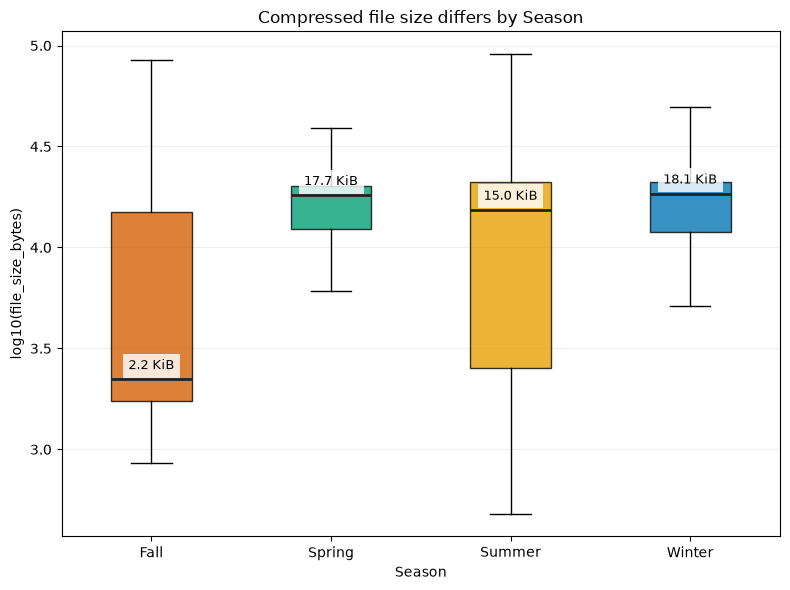

In [43]:
box_order = ["Fall", "Spring", "Summer", "Winter"]
log_file_sizes = [
    np.log10(
        season_development.loc[
            season_development["season"].eq(season_name), "file_size_bytes"
        ].to_numpy()
    )
    for season_name in box_order
]
figure, axis = plt.subplots(figsize=(8, 6))
boxplot = axis.boxplot(
    log_file_sizes,
    tick_labels=box_order,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "#222222", "linewidth": 2},
)
for patch, season_name in zip(boxplot["boxes"], box_order):
    patch.set_facecolor(season_colors[season_name])
    patch.set_alpha(0.78)
for position, season_name in enumerate(box_order, start=1):
    median_bytes = float(season_medians.loc[season_name, "median_file_size_bytes"])
    median_kib = float(season_medians.loc[season_name, "median_file_size_kib"])
    axis.text(
        position,
        np.log10(median_bytes) + 0.035,
        f"{median_kib:.1f} KiB",
        ha="center",
        va="bottom",
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.82, "edgecolor": "none"},
    )
axis.set_title("Compressed file size differs by Season")
axis.set_xlabel("Season")
axis.set_ylabel("log10(file_size_bytes)")
axis.grid(axis="y", alpha=0.2)
figure.tight_layout()
_ = save_figure(figure, "season_file_size_shortcut.png")
plt.show()


**Finding.** Fall has a median compressed size of only 2.2 KiB, compared with 15.0-18.1 KiB for Spring, Summer, and Winter. File size may therefore reveal collection or compression history, but this difference is neither causal proof nor model performance.

### 4.4 Development image profile and pixel diagnostics

**Purpose.** Describe geometry and a fixed sample of simple pixel properties. These
diagnostics are explicitly forbidden as fitted model statistics.


#### 4.4.1 Image dimensions and modes

In [44]:
image_profile_path = ROOT / "data/processed/development_image_profile.json"
image_profile = json.loads(image_profile_path.read_text(encoding="utf-8"))
grayscale_products = int(development["mode"].eq("L").sum())
nonstandard_size_products = int(
    (~development["width"].eq(60) | ~development["height"].eq(80)).sum()
)
profile_table = pd.DataFrame(
    [
        ("rows", image_profile["rows"], "products"),
        ("width", image_profile["width"]["minimum"], image_profile["width"]["maximum"]),
        ("height", image_profile["height"]["minimum"], image_profile["height"]["maximum"]),
        (
            "aspect_ratio",
            image_profile["aspect_ratio"]["minimum"],
            image_profile["aspect_ratio"]["maximum"],
        ),
        ("grayscale images", grayscale_products, "retained"),
        ("images not 60 x 80", nonstandard_size_products, "retained"),
        ("allowed_for_model_fit", image_profile["allowed_for_model_fit"], "must be false"),
    ],
    columns=["fact", "minimum_or_value", "maximum_or_note"],
)
display(profile_table)
print(f"Read {relative(image_profile_path)} | sha256={sha256_file(image_profile_path)}")
assert image_profile["allowed_for_model_fit"] is False


,fact,minimum_or_value,maximum_or_note
0,rows,32773,products
1,width,53.0,60.0
2,height,60.0,80.0
3,aspect_ratio,0.6625,1.0
4,grayscale images,294,retained
5,images not 60 x 80,12,retained
6,allowed_for_model_fit,False,must be false


Read data/processed/development_image_profile.json | sha256=9e0a90263ab6bf93af045b04132627c40d5d67a7a4ae686f5299c4f51c72c2f9


**Finding.** Within development, there are 294 grayscale images (about 0.9%) and 12 non-60 x 80 images; observed sizes range from 53-60 pixels wide and 60-80 high. These are development counts, not a claim that such images are absent from holdout. Later task transforms must handle these cases, while `allowed_for_model_fit: false` stops this profile becoming a fitted setting.

#### 4.4.2 Quality-sample definition

In [45]:
QUALITY_SAMPLE_SIZE = min(1024, len(development))
quality_members = development.sample(n=QUALITY_SAMPLE_SIZE, random_state=RANDOM_SEED).sort_values(
    "id"
)


def simple_image_quality(row: pd.Series) -> dict[str, object]:
    path = ROOT / str(row["path"])
    with Image.open(path) as source:
        rgb = np.asarray(source.convert("RGB"), dtype=np.float32) / 255.0
    gray = rgb.mean(axis=2)
    edge_x = np.abs(np.diff(gray, axis=1)).mean() if gray.shape[1] > 1 else 0.0
    edge_y = np.abs(np.diff(gray, axis=0)).mean() if gray.shape[0] > 1 else 0.0
    return {
        "id": int(row["id"]),
        "path": str(row["path"]),
        "width": float(row["width"]),
        "height": float(row["height"]),
        "aspect_ratio": float(row["aspect_ratio"]),
        "file_size_bytes": int(float(row["file_size_bytes"])),
        "brightness": float(gray.mean()),
        "contrast": float(gray.std()),
        "edge_strength": float((edge_x + edge_y) / 2),
        "near_white_fraction": float((gray > 0.95).mean()),
    }

"definition-only: deterministic pixel-quality measures are ready"


'definition-only: deterministic pixel-quality measures are ready'

**Definition only.** A seed-2753 sample of 1,024 development images records five independent kinds of image quality using file size and simple pixel measures. The calculations are independent, but the later correlation check tests whether the resulting columns carry overlapping information.

#### 4.4.3 Quality-sample summary

In [46]:
quality_sample = pd.DataFrame([simple_image_quality(row) for _, row in quality_members.iterrows()])
display(quality_sample.describe().T.round(4))
_ = write_table(quality_sample, "development_image_quality_sample.csv")


,count,mean,std,min,25%,50%,75%,max
id,1024.0,26480.5352,14561.2810,1790.0000,13782.5000,26530.5000,39001.5000,51901.0000
width,1024.0,60.0000,0.0000,60.0000,60.0000,60.0000,60.0000,60.0000
height,1024.0,80.0000,0.0000,80.0000,80.0000,80.0000,80.0000,80.0000
aspect_ratio,1024.0,0.7500,0.0000,0.7500,0.7500,0.7500,0.7500,0.7500
file_size_bytes,1024.0,12254.1211,10047.2866,816.0000,2154.0000,13491.0000,20012.0000,62709.0000
brightness,1024.0,0.8348,0.0899,0.3771,0.7754,0.8426,0.9029,0.9951
contrast,1024.0,0.2490,0.0834,0.0284,0.1930,0.2549,0.3098,0.4486
edge_strength,1024.0,0.0309,0.0137,0.0033,0.0202,0.0301,0.0398,0.0803
near_white_fraction,1024.0,0.6676,0.1541,0.0000,0.5671,0.6610,0.7885,0.9719


Wrote results/evidence/data_preparation/development_image_quality_sample.csv | rows=1,024 | sha256=64344c7a291d6cb3eb6e6d5a6bfd1b1d1b17c9b4c89894c9b988fe751baf2177


**Finding.** The sample is generally bright (mean 0.835) with moderate contrast (mean 0.249), while brightness spans 0.377-0.995 and edge strength spans 0.003-0.080. Showing these scales first makes the later extreme examples interpretable instead of arbitrary.

#### 4.4.4 Pixel-correlation results

In [47]:
pixel_diagnostic_columns = [
    "file_size_bytes",
    "brightness",
    "contrast",
    "edge_strength",
    "near_white_fraction",
]
spearman = quality_sample[pixel_diagnostic_columns].corr(method="spearman")
spearman_long = (
    spearman.rename_axis("feature_1")
    .reset_index()
    .melt(id_vars="feature_1", var_name="feature_2", value_name="spearman_rho")
)
_ = write_table(spearman_long, "image_quality_spearman.csv")
spearman_focus = pd.DataFrame(
    [
        {
            "relationship": "brightness - contrast",
            "spearman_rho": float(spearman.loc["brightness", "contrast"]),
        },
        {
            "relationship": "brightness - white-background share",
            "spearman_rho": float(
                spearman.loc["brightness", "near_white_fraction"]
            ),
        },
    ]
)
display(spearman_focus.round(3))


Wrote results/evidence/data_preparation/image_quality_spearman.csv | rows=25 | sha256=153f26744cc54cec363dbf3b80e6f81bda64dae72e22ff606952a984db2215b7


,relationship,spearman_rho
0,brightness - contrast,-0.862
1,brightness - white-background share,0.792


**Finding.** Brightness and contrast have a strong negative Spearman relationship (-0.862), while brightness and near-white background share move together (0.792). The diagnostics therefore overlap and should not be presented as five unrelated data-quality problems.

#### 4.4.5 Pixel-diagnostic distributions

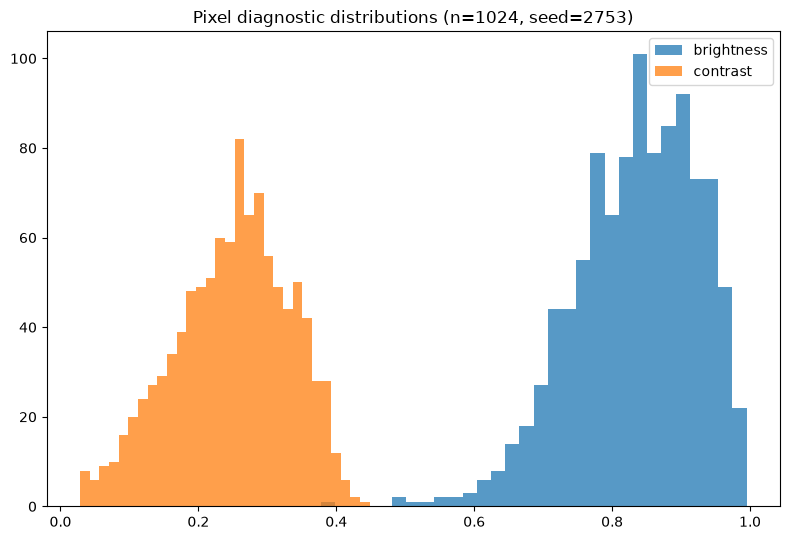

In [48]:
figure, axis = plt.subplots(figsize=(8, 5.5))
axis.hist(quality_sample["brightness"], bins=30, alpha=0.75, label="brightness")
axis.hist(quality_sample["contrast"], bins=30, alpha=0.75, label="contrast")
axis.set_title(f"Pixel diagnostic distributions (n={QUALITY_SAMPLE_SIZE}, seed={RANDOM_SEED})")
axis.legend()
figure.tight_layout()
_ = save_figure(figure, "image_quality_distributions.png")
plt.show()


**Finding.** Brightness clusters toward the high end, whereas contrast is centred much lower, matching the catalogue's mostly light backgrounds. The plot shows population shape rather than setting an automatic rejection threshold for dark or low-contrast products.

#### 4.4.6 Pixel-diagnostic correlation

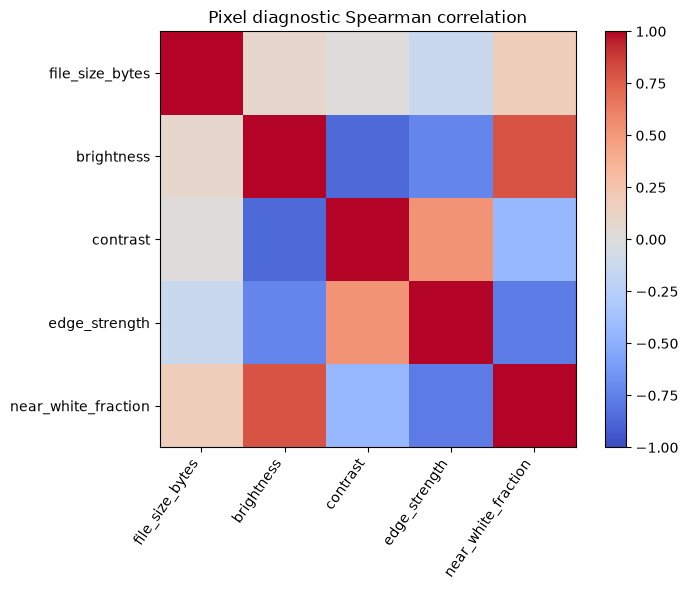

In [49]:
figure, axis = plt.subplots(figsize=(7.5, 6))
matrix = axis.imshow(spearman.to_numpy(), vmin=-1, vmax=1, cmap="coolwarm")
axis.set_xticks(
    range(len(pixel_diagnostic_columns)),
    pixel_diagnostic_columns,
    rotation=55,
    ha="right",
)
axis.set_yticks(range(len(pixel_diagnostic_columns)), pixel_diagnostic_columns)
axis.set_title("Pixel diagnostic Spearman correlation")
figure.colorbar(matrix, ax=axis, fraction=0.046)
figure.tight_layout()
_ = save_figure(figure, "image_quality_spearman.png")
plt.show()


**Finding.** The full matrix confirms that several pixel diagnostics move together, especially brightness, contrast, edge strength, and white-background share. Exact coefficients remain in CSV, while the heatmap provides a quick check against treating correlated columns as separate evidence.

### 4.5 Labelled development contact sheet

**Purpose.** Make metadata-image mismatches visible. A fixed seed selects development
rows only; every image is shown with its ID and all four target tags.


#### 4.5.1 Labelled development sample

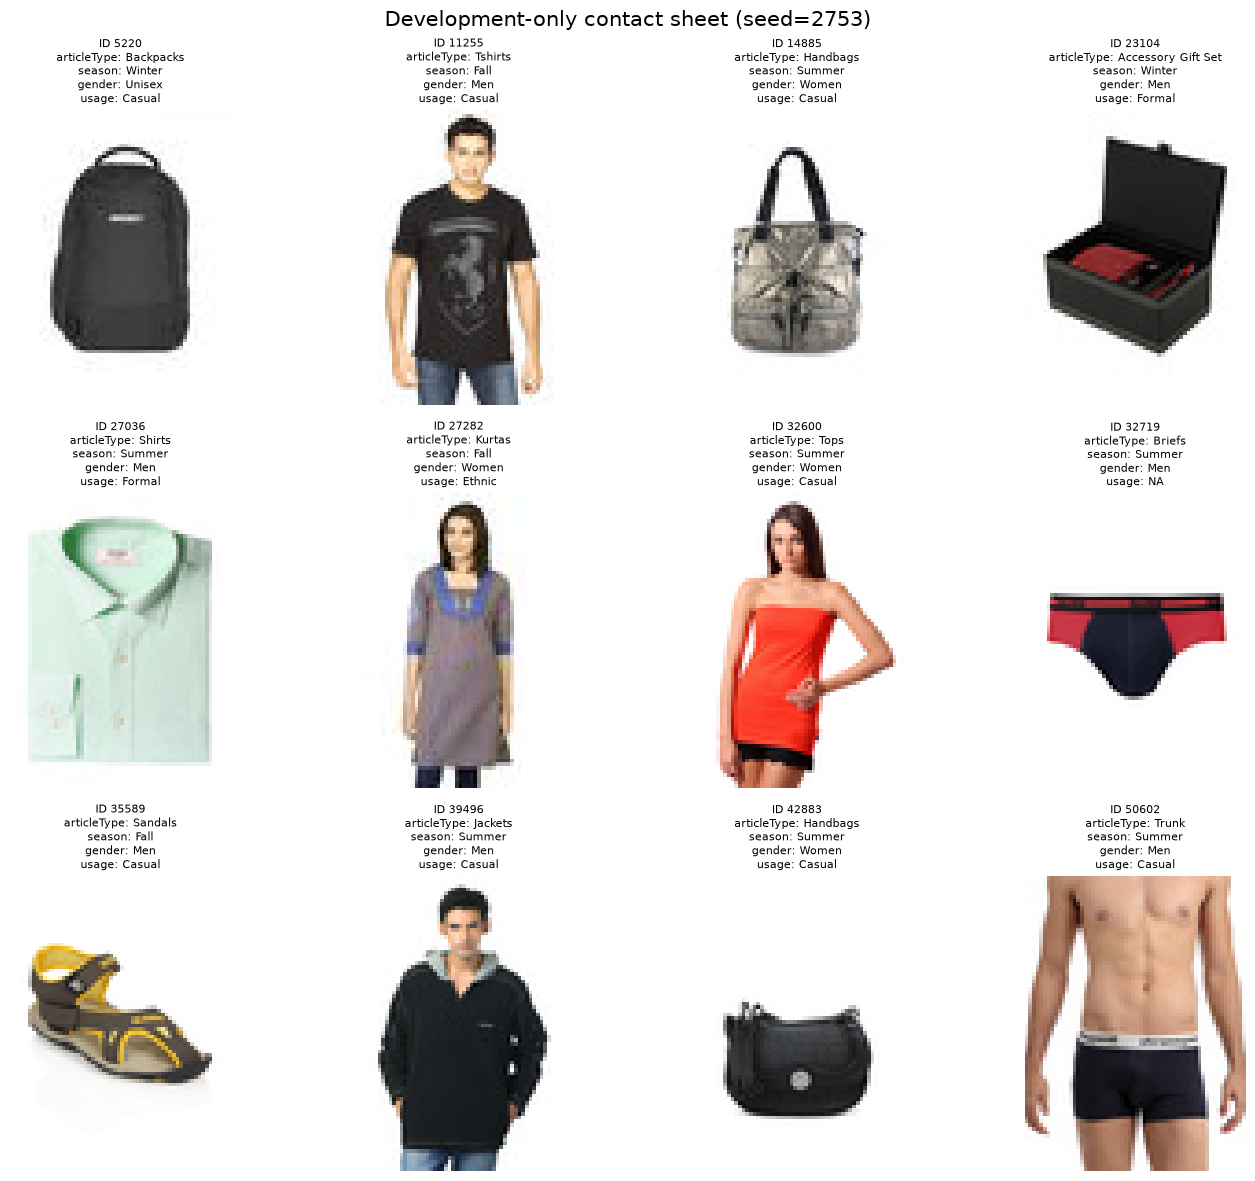

Wrote results/evidence/data_preparation/development_contact_sheet_index.csv | rows=12 | sha256=51c1095b102393a3577eed529ed949501672d21b58dcf2514442fa73a2ee989e


In [50]:
CONTACT_SHEET_SIZE = 12
contact_rows = development.sample(n=CONTACT_SHEET_SIZE, random_state=RANDOM_SEED).sort_values("id")
figure, axes = plt.subplots(3, 4, figsize=(14, 12))
contact_index = []
for axis, (_, row) in zip(axes.ravel(), contact_rows.iterrows()):
    with Image.open(ROOT / str(row["path"])) as source:
        axis.imshow(source.convert("RGB"))
    tags = "\n".join(f"{target}: {row[target] or '<missing>'}" for target in TARGETS)
    axis.set_title(f"ID {int(row['id'])}\n{tags}", fontsize=8)
    axis.axis("off")
    contact_index.append(
        {
            "id": int(row["id"]),
            "path": str(row["path"]),
            **{target: row[target] for target in TARGETS},
        }
    )
figure.suptitle(f"Development-only contact sheet (seed={RANDOM_SEED})", fontsize=15)
figure.tight_layout()
figure_record = save_figure(figure, "development_contact_sheet.png")
plt.show()
_ = write_table(pd.DataFrame(contact_index), "development_contact_sheet_index.csv")


**Finding.** Twelve seed-fixed development images are shown with all four labels and recorded in a separate index, tying every pixel example to its metadata row. The sheet reveals visual variety, but it does not prove that every teacher label is visible or learnable from the image.

### 4.6 Duplicate, missing-image, and quality-extreme examples

**Purpose.** Show concrete failure modes instead of reporting only aggregate counts.


#### 4.6.1 Example selection

In [51]:
duplicate_sizes = development.groupby("duplicate_group")["id"].transform("size")
duplicate_examples = (
    development[duplicate_sizes.gt(1)].sort_values(["duplicate_group", "id"]).head(2)
)
quality_extremes = pd.concat(
    [
        quality_sample.nsmallest(1, "brightness").assign(
            example_reason="lowest sampled brightness"
        ),
        quality_sample.nlargest(1, "brightness").assign(
            example_reason="highest sampled brightness"
        ),
        quality_sample.nsmallest(1, "edge_strength").assign(
            example_reason="lowest sampled edge strength"
        ),
    ],
    ignore_index=True,
).drop_duplicates("id")

"definition-only: duplicate and pixel-extreme examples selected"


'definition-only: duplicate and pixel-extreme examples selected'

**Definition only.** The first eligible exact-duplicate group and the lowest-brightness, highest-brightness, and lowest-edge sample members are selected by fixed rules before plotting. This avoids hand-picking examples after seeing which images make the strongest story.

#### 4.6.2 Exact duplicate example

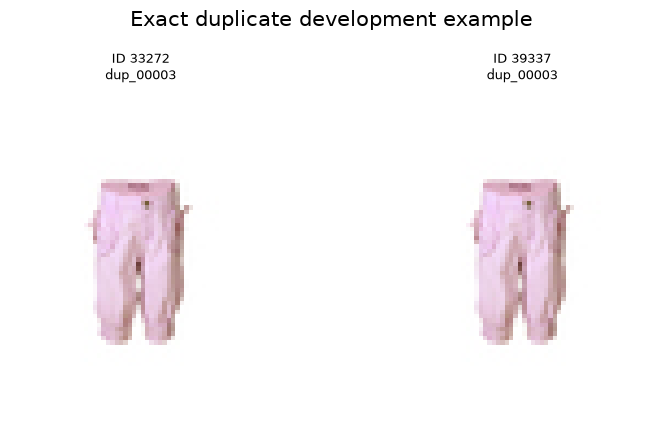

In [52]:
figure, axes = plt.subplots(1, 2, figsize=(8, 4.5))
example_index = []
for axis, (_, row) in zip(axes, duplicate_examples.iterrows()):
    with Image.open(ROOT / str(row["path"])) as source:
        axis.imshow(source.convert("RGB"))
    axis.set_title(
        f"ID {int(row['id'])}\n{row['duplicate_group']}",
        fontsize=9,
    )
    axis.axis("off")
    example_index.append(
        {"id": int(row["id"]), "reason": "exact duplicate", "path": str(row["path"])}
    )
figure.suptitle("Exact duplicate development example", fontsize=15)
figure.tight_layout()
_ = save_figure(figure, "exact_duplicate_examples.png")
plt.show()


**Finding.** IDs 33272 and 39337 share duplicate group `dup_00003` and display the same product pixels. Keeping them in one conservative split group prevents an identical image from making validation performance look better than true generalisation.

#### 4.6.3 Missing-image IDs

In [53]:
missing_image_examples = pd.DataFrame(
    {"id": sorted(known_missing), "issue": "metadata row has no valid image"}
)
display(missing_image_examples)


,id,issue
0,12347,metadata row has no valid image
1,39401,metadata row has no valid image
2,39403,metadata row has no valid image
3,39410,metadata row has no valid image
4,39425,metadata row has no valid image


**Finding.** The table keeps all five missing-image metadata IDs visible even though there are no pixels to display or train on. Naming them here distinguishes unavailable files from corrupt supported images and makes the earlier reconciliation count easy to verify.

#### 4.6.4 Pixel-quality extremes

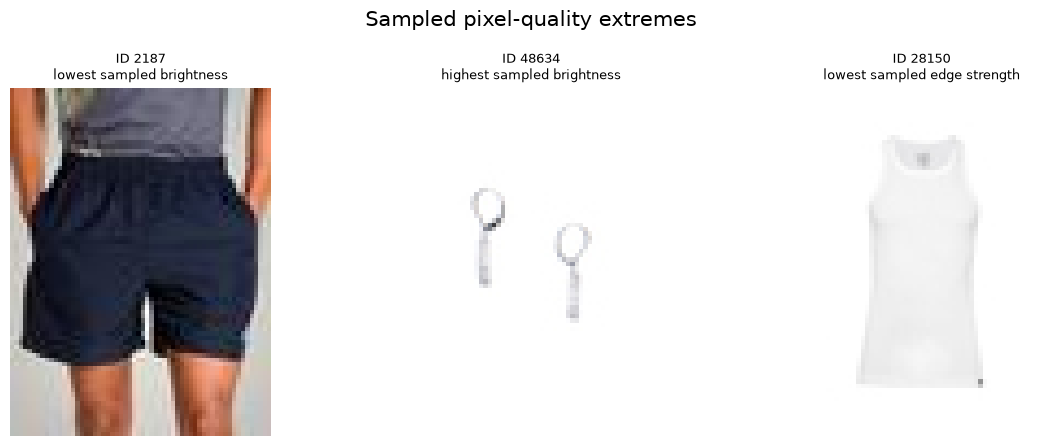

Wrote results/evidence/data_preparation/data_quality_example_index.csv | rows=5 | sha256=974d1bae77d88a309a264ddeba77edd8046ecc53d7c7f29eb476dd35ba912f84


In [54]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4.5))
for axis, row in zip(axes, quality_extremes.itertuples(index=False)):
    with Image.open(ROOT / row.path) as source:
        axis.imshow(source.convert("RGB"))
    axis.set_title(f"ID {row.id}\n{row.example_reason}", fontsize=9)
    axis.axis("off")
    example_index.append(
        {"id": int(row.id), "reason": row.example_reason, "path": row.path}
    )
figure.suptitle("Sampled pixel-quality extremes", fontsize=15)
figure.tight_layout()
_ = save_figure(figure, "quality_extreme_examples.png")
plt.show()
_ = write_table(pd.DataFrame(example_index), "data_quality_example_index.csv")


**Finding.** IDs 2187, 48634, and 28150 represent the sampled lowest brightness, highest brightness, and lowest edge strength. Their images show that an extreme diagnostic can reflect normal product photography, so these values are review evidence rather than automatic exclusion rules.

### 4.7 Transform-risk illustration

**Purpose.** Demonstrate how stretch, centre crop, and padding alter the same source.
This is a risk illustration only; no final size or transform is selected here.


#### 4.7.1 Transform-view definition

In [55]:
def transform_risk_views(
    source: Image.Image, canvas: tuple[int, int] = (160, 160)
) -> dict[str, Image.Image]:
    rgb = source.convert("RGB")
    return {
        "source": rgb,
        "stretch": rgb.resize(canvas, Image.Resampling.BILINEAR),
        "centre_crop": ImageOps.fit(
            rgb, canvas, method=Image.Resampling.BILINEAR, centering=(0.5, 0.5)
        ),
        "pad": ImageOps.pad(
            rgb,
            canvas,
            method=Image.Resampling.BILINEAR,
            color=(255, 255, 255),
            centering=(0.5, 0.5),
        ),
    }


"definition-only: visual transform comparison; no task policy is chosen"


'definition-only: visual transform comparison; no task policy is chosen'

**Definition only.** One source image is rendered as the original, a 160 x 160 stretch, a centre crop, and a padded square. These views expose geometry, content-loss, and border risks without selecting a shared transform for any modelling task.

#### 4.7.2 Side-by-side transform comparison

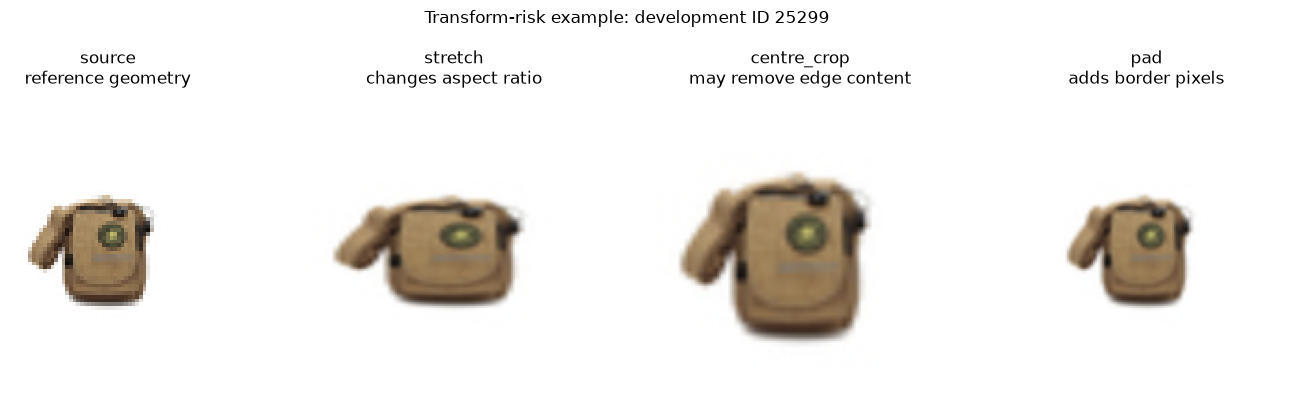

Wrote results/evidence/data_preparation/transform_risk_examples.csv | rows=4 | sha256=3acb785e0420e2e614537da09b7b58f3d7428e73ee3ba2d2971a0403965beeb7


In [56]:
transform_row = development.sort_values(["aspect_ratio", "id"]).iloc[0]
with Image.open(ROOT / str(transform_row["path"])) as source:
    views = transform_risk_views(source)
figure, axes = plt.subplots(1, 4, figsize=(14, 4))
risk_notes = {
    "source": "reference geometry",
    "stretch": "changes aspect ratio",
    "centre_crop": "may remove edge content",
    "pad": "adds border pixels",
}
for axis, (name, view) in zip(axes, views.items()):
    axis.imshow(view)
    axis.set_title(f"{name}\n{risk_notes[name]}")
    axis.axis("off")
figure.suptitle(f"Transform-risk example: development ID {int(transform_row['id'])}")
figure.tight_layout()
figure_record = save_figure(figure, "transform_risk.png")
plt.show()
transform_risk = pd.DataFrame(
    [{"id": int(transform_row["id"]), "method": name, "risk": risk_notes[name]} for name in views]
)
_ = write_table(transform_risk, "transform_risk_examples.csv")


**Finding.** Stretching changes the product's shape, centre cropping can remove edge content, and padding adds artificial border pixels while preserving geometry. No option is harmless, so each task must compare transform choices using training folds only.

### 4.8 EDA synthesis and task-linked pre-training hypotheses

**Scientific status.** This register was added retrospectively to make the intended
development-only reasoning explicit. It reconstructs questions that follow from the
EDA, but it does **not** claim formal preregistration before the completed experiments.
It contains no downstream model result and does not mark any hypothesis as supported
or rejected. Those judgements belong in the relevant task notebook.

**Compact EDA finding register.**

| Finding | Development-only observation | Why it matters before training |
|---|---|---|
| F01 — Source integrity | The labelled CSV has 38,617 unique IDs but only 38,613 image files; five metadata IDs have no valid image. All 5,829 prediction IDs have usable images. | Missing pixels must remain explicit, while prediction generation can require one valid image per requested ID. |
| F02 — Related products | The 32,773 development products form 22,905 conservative groups; 41.89% of products are in multi-row groups, the largest group has 80 rows, and 61 unsafe rows are quarantined. | Product rows are not all independent observations. Duplicate or family leakage could inflate validation and retrieval evidence. |
| F03 — Protected split | Development, holdout, and quarantine contain 32,773, 5,778, and 61 rows, with zero active family or duplicate crossings. | Every later comparison must reuse these memberships and the five saved family-safe folds. |
| F04 — Label availability | Development contains 124 ArticleType, 4 Season, 5 Gender, and 9 Usage classes; 20 Season labels and one Usage label are blank. | A missing target needs a mask, not an invented class or imputed label. |
| F05 — Long tails | ArticleType and Usage have largest-to-smallest class ratios of 5,748:1 and 25,151:1. Twenty-six ArticleType classes trigger low-support warnings; 12 ArticleType classes and Usage `Home` have at least one zero-training fold case. | Accuracy alone can hide unusable minority-class behaviour, and some fold/class scores cannot represent learned performance. |
| F06 — Catalogue associations | ArticleType–Usage is the strongest target-pair NMI at 0.254. An ArticleType-majority lookup reaches about 65.0% Season, 78.5% Gender, and 90.0% Usage agreement. | Later models may exploit catalogue structure that works in-distribution but fails on unusual target combinations. |
| F07 — Season acquisition pattern | 2011–2012 provide 69.9% of valid-Season rows; year-majority agreement is 74.5% versus a 49.6% global-majority agreement. Fall's median compressed size is 2.2 KiB versus 15.0–18.1 KiB for the other seasons. | Season evidence may partly reflect collection or compression history rather than transferable clothing cues. |
| F08 — Image variation | Development includes 294 grayscale images and 12 non-60 × 80 images. Brightness, contrast, edge strength, and near-white background share are not independent diagnostics. | Input conversion must handle real variants, and robustness claims must separate correlated acquisition properties. |
| F09 — Transform risk | Stretching changes shape, centre cropping can remove edge content, and padding introduces borders. | A transform is a modelling choice that needs comparison; Notebook 01 must not silently choose one for every task. |

**Research questions and safeguards for Tasks 1–4.**

H01–H04 are empirical questions; H05–H06 are required safeguards, not hypotheses to reject. H07 records an external-validity question. The links below point to the relevant existing analyses. A named comparison is not a claim that every part was completed: the task notebook must report the evidence available and any remaining gap. No new threshold or decision rule is presented as having been fixed before the completed experiments.

| Entry | Derived from | Task-linked expectation or safeguard | Comparison, evidence, and limit |
|---|---|---|---|
| H01 — Rare ArticleType performance | F04–F05 | Classes with less training support are expected to have lower recall and greater fold-to-fold variation than well-supported classes. | See [Task 1, Sections 11–13](02_task1_part1_article_type.ipynb#11.-Combined-five-fold-and-OOF-comparison). Compare per-class recall and its fold variation against each fold's training support, using the same validation rows for baseline and image models. Report macro-F1 alongside accuracy and flag zero-training cases separately. No lower recall or greater variation among low-support classes would count against the expectation; wide uncertainty leaves it unresolved. |
| H02 — Season shortcut sensitivity | F06–F07 | Season errors may increase for ArticleType-conflict cases or after changes to compression-linked visual cues. | See [Task 2, Sections 10–11](04_task2_part1_season.ipynb#10.-Error-and-shortcut-analysis) and [its evaluation, Sections 10–11](05_task2_part2_final_evaluation.ipynb#10.-EDA-reflection-and-predeclared-slices). Compare aligned/conflict error rates with class counts, and clean versus perturbed predictions on the same images using macro-F1 and per-class recall. Report year and file-size slices separately. No consistent excess error or paired performance drop would count against sensitivity to the tested conditions. Slice differences alone do not establish a causal shortcut. |
| H03 — Gender and Usage catalogue shortcuts | F04–F06 | Gender and Usage errors are expected to be higher on combinations that conflict with the training-fold ArticleType-majority label. | See [Task 3, Section 8](06_task3_part1_gender_usage.ipynb#8.-Shared-EDA:-target-relationships-and-shortcuts) and [its evaluation, Section 10](07_task3_part2_final_evaluation.ipynb#10.-Error,-robustness,-and-cost-analysis). Build each majority lookup from training rows only; compare aligned/conflict error rates on the held-out fold with target-class counts and per-class recall. Report class-mix differences and uncertainty. No consistent excess conflict error within comparable classes would count against this expectation; a raw gap alone does not identify its cause. |
| H04 — Input robustness | F08–F09 | Removing colour, changing geometry, or degrading image quality may reduce classification performance. | See [Task 1, Sections 6 and 9](02_task1_part1_article_type.ipynb#6.-Controlled-preprocessing), [Task 2, Section 11](04_task2_part1_season.ipynb#11.-Robustness-and-efficiency), and [Task 3 evaluation, Section 10.7](07_task3_part2_final_evaluation.ipynb#10.7-Robustness-evidence-and-its-limits). For each tested perturbation, state its strength and compare the same frozen model on clean and changed versions of the same evaluation images. Report paired macro-F1 changes, per-class recall, and uncertainty. An absent or reversed drop counts against harm from that particular perturbation; untested changes remain unknown. Training-recipe comparisons address a different question and must be identified separately. |
| H05 — Retrieval safeguards | F02–F03 | Prevent overlap that invalidates the chosen retrieval question, while retaining legitimate same-family positives for family recovery. | See [Task 4, Section 2](task-4/09_task4_part2_visual_search.ipynb#2.-Data-and-task-output). Protocol A uses fold-1 queries and a gallery from the other folds, with duplicate and family isolation. Protocol B deliberately uses fold 1 for both roles, removes self-matches and exact duplicates, and measures same-family recovery. Report Protocol A nDCG and Protocol B family Recall separately, with coverage and boundary checks. Useful leakage-safe rankings do not measure how much leakage would inflate a score; no such effect size is claimed here, and the frozen split and protocols remain unchanged. |
| H06 — Missing-label safeguard | F04–F05 | An absent target provides no supervised label for that target; it must not become an invented class. | Verify target-presence masks, exclusion of missing targets from the relevant loss and score, and preservation of the original label map. This is a data-contract check, not an empirical hypothesis. The literal Usage label `NA` remains a real class and must not be confused with a blank. Any alternative supervision method requires separate evidence and a documented assumption. |
| H07 — External-validity question | F01, F07–F09 | Performance may fall on a separately collected catalogue or camera source. | See [Task 3 evaluation, Section 15](07_task3_part2_final_evaluation.ipynb#15.-Future-improvements-to-the-process-and-results) for future evaluation needs. A test requires frozen models and a separately collected, labelled set with product overlap removed. Compare macro-F1 and per-class recall with source and class counts, uncertainty, and label-policy differences reported. No drop would support transfer only to that tested source. Synthetic perturbations and same-source holdout scores do not replace this evidence; where independent data are absent, transfer remains untested. |

For the falsifiable empirical questions, the intended reasoning is:
**observation → hypothesis → controlled comparison → independent evaluation → qualified
judgement**. “Falsifiable” means that the later test names evidence that could show the
hypothesis is wrong, not only evidence that agrees with it. The safeguard entries instead require contract checks; passing them does not confirm a performance hypothesis.

The shortcut interpretation follows
[Geirhos et al. (2020), *Shortcut Learning in Deep Neural Networks*](https://doi.org/10.1038/s42256-020-00257-z).
The protected group and holdout boundary is consistent with the leakage risks reviewed
by [Kapoor and Narayanan (2023)](https://doi.org/10.1016/j.patter.2023.100804).
These sources justify the questions and safeguards; they do not substitute for evidence
from this dataset.


## 5. Reproducible artifacts and downstream handoff

**Purpose.** Freeze artifact lineage, show the supported fold-access interface,
and fail loudly if any shared-data safeguard is incomplete.


### 5.1 Artifact registry and lineage

**Purpose.** Record how each artifact was produced, where it may be used, and its
current hash.
`development_image_profile.json` remains description-only.


#### 5.1.1 Artifact lineage

In [57]:
lineage = pd.DataFrame(
    [
        (
            "teacher CSV header + ordered IDs",
            "audit_raw_data",
            "audit/csv_summary.json",
            "structure and reconciliation",
        ),
        (
            "teacher image raw bytes",
            "audit_raw_data",
            "audit/image_audit.csv.gz",
            "integrity and exact hashes",
        ),
        (
            "image hashes + perceptual candidates + names",
            "build_product_families",
            "audit/product_family_groups.csv.gz",
            "group boundary",
        ),
        ("fixed IDs + family groups", "make_splits", "splits.csv", "all task notebooks"),
        (
            "development labels only",
            "write_label_maps_from_splits",
            "label_maps.json",
            "task-local encoders",
        ),
        (
            "development image facts",
            "write_development_image_profile",
            "development_image_profile.json",
            "description only",
        ),
    ],
    columns=["input_scope", "producer", "artifact", "consumer_or_limit"],
)
display(lineage)
_ = write_table(lineage, "lineage.csv")


,input_scope,producer,artifact,consumer_or_limit
0,teacher CSV header + ordered IDs,audit_raw_data,audit/csv_summary.json,structure and reconciliation
1,teacher image raw bytes,audit_raw_data,audit/image_audit.csv.gz,integrity and exact hashes
2,image hashes + perceptual candidates + names,build_product_families,audit/product_family_groups.csv.gz,group boundary
3,fixed IDs + family groups,make_splits,splits.csv,all task notebooks
4,development labels only,write_label_maps_from_splits,label_maps.json,task-local encoders
5,development image facts,write_development_image_profile,development_image_profile.json,description only


Wrote results/evidence/data_preparation/lineage.csv | rows=6 | sha256=99f062febd51ab5f94b76d7ef88f4e1e62a6060b62a195553174f1c61ec4afc2


**Finding.** Six lineage rows connect teacher structure and image bytes to family groups, the canonical split, label maps, and the descriptive image profile. Each row also names its consumer or limit, making it clear which artifacts may guide modelling and which remain audit-only.

#### 5.1.2 Provenance record

In [58]:
provenance = {
    "schema_version": "1.0.0",
    "shared_source_policy": "teacher_only",
    "development_eda_only": True,
    "acquisition_shortcut_scope": "development_rows_with_valid_season_only",
    "broad_name_review_scope": "development_only_evidence_no_pipeline_feedback",
    "protected_target_values_used": 0,
    "cv_seed": RANDOM_SEED,
    "cv_folds": 5,
    "cv_assignment_sha256": current_cv_digest,
    "product_name_na_policy": "missing_for_name_and_family_only",
    "usage_na_policy": "valid_teacher_label",
    "model_fit_allowed": False,
    "lineage_file": "results/evidence/data_preparation/lineage.csv",
}
provenance_path = EVIDENCE_DIR / "provenance.json"
provenance_path.write_text(
    json.dumps(provenance, indent=2, sort_keys=True) + "\n", encoding="utf-8"
)
print(f"Wrote {relative(provenance_path)} | sha256={sha256_file(provenance_path)}")


Wrote results/evidence/data_preparation/provenance.json | sha256=7b7476fac9b3e509bce67014c105f38609e891b470b282b133d3f27961f3ddf1


**Finding.** The record freezes teacher-only scope, development-only EDA, seed 2753, five folds, the CV digest, and zero protected target use. It also marks model fitting as disallowed, so downstream code can check the preparation contract without interpreting notebook prose.

#### 5.1.3 Preparation summary

In [59]:
preparation_summary = {
    "schema_version": "1.0.0",
    "status": "ready",
    "partition_counts": {
        key: int(value) for key, value in splits["partition"].value_counts().items()
    },
    "cv_fold_counts": {
        str(int(key)): int(value)
        for key, value in development["cv_fold"].value_counts().sort_index().items()
    },
    "cv_assignment_sha256": current_cv_digest,
    "development_conservative_split_groups": int(
        profile["conservative_split_groups"]
    ),
    "acquisition_shortcut": {
        "valid_season_rows": int(len(season_development)),
        "share_in_2011_2012": float(share_2011_2012),
        "global_majority_agreement": float(global_majority_agreement),
        "year_majority_agreement": float(year_majority_agreement),
    },
    "broad_name_family_review": {
        "groups": int(BROAD_NAME_GROUP_COUNT),
        "samples_per_group": int(BROAD_NAME_SAMPLE_SIZE),
        "largest_group_name": str(selected_name_groups.iloc[0]["display_name"]),
        "largest_group_rows": int(selected_name_groups.iloc[0]["group_size"]),
    },
    "official_prediction_rows": 5829,
    "known_labelled_ids_without_valid_image": [12347, 39401, 39403, 39410, 39425],
    "active_group_crossings": int(
        group_boundary_audit[["active_partition_crossings", "development_fold_crossings"]]
        .to_numpy()
        .sum()
    ),
    "protected_target_values_used": 0,
    "model_training_runs": 0,
}
summary_path = EVIDENCE_DIR / "summary.json"
summary_path.write_text(
    json.dumps(preparation_summary, indent=2, sort_keys=True) + "\n", encoding="utf-8"
)
print(f"Wrote {relative(summary_path)} | sha256={sha256_file(summary_path)}")


Wrote results/evidence/data_preparation/summary.json | sha256=bfa04de1ef381801d72e88d2d607503e4f795a08102dd6fdee2535d581f54865


**Finding.** The machine-readable summary repeats the ready status, partition and fold counts, grouping facts, and the main acquisition and quality warnings. It gives later tasks a compact handoff while leaving the full tables and figures as the detailed evidence.

#### 5.1.4 Required artifact set

In [60]:
expected_evidence_files = [
    "raw_inventory.csv",
    "preparation_stage_order.csv",
    "raw_hashing_summary.csv",
    "image_reconciliation.csv",
    "duplicate_family_summary.csv",
    "broad_name_family_review_index.csv",
    "group_boundary_audit.csv",
    "perceptual_scope_audit.csv",
    "partition_summary.csv",
    "cv_fold_balance.csv",
    "target_summary.csv",
    "imbalance_handoff.csv",
    "joint_target_nmi.csv",
    "acquisition_shortcut_summary.csv",
    "development_image_quality_sample.csv",
    "image_quality_spearman.csv",
    "development_contact_sheet_index.csv",
    "data_quality_example_index.csv",
    "transform_risk_examples.csv",
    "lineage.csv",
    "provenance.json",
    "summary.json",
]
expected_figure_files = [
    "target_distributions.png",
    "family_size_profile.png",
    "family_group_evidence.png",
    "broad_name_family_review.png",
    "near_duplicate_threshold_review.png",
    "class_support_products_vs_groups.png",
    "rare_class_fold_support.png",
    "shortcut_risk_heatmaps.png",
    "shortcut_majority_benchmark.png",
    "acquisition_shortcut_risk.png",
    "season_file_size_shortcut.png",
    "joint_target_nmi.png",
    "image_quality_distributions.png",
    "image_quality_spearman.png",
    "development_contact_sheet.png",
    "exact_duplicate_examples.png",
    "quality_extreme_examples.png",
    "transform_risk.png",
]
main_artifacts = [
    "data/processed/splits.csv",
    "data/processed/split_summary.json",
    "data/processed/cv_fold_summary.json",
    "data/processed/prediction_manifest.csv",
    "data/processed/taxonomy.json",
    "data/processed/label_maps.json",
    "data/processed/development_class_summary.csv",
    "data/processed/development_image_profile.json",
    "data/processed/preparation_cache.json",
    "data/processed/audit/csv_summary.json",
    "data/processed/audit/image_audit.csv.gz",
    "data/processed/audit/exact_duplicate_groups.csv",
    "data/processed/audit/near_duplicate_candidates.csv.gz",
    "data/processed/audit/product_family_groups.csv.gz",
    *[f"results/evidence/data_preparation/{name}" for name in expected_evidence_files],
    *[f"results/figures/data_preparation/{name}" for name in expected_figure_files],
]
missing_artifacts = sorted(
    repository_path
    for repository_path in set(main_artifacts)
    if not (ROOT / repository_path).is_file()
)
assert not missing_artifacts, f"Required artifacts are missing: {missing_artifacts}"

f"Validated {len(set(main_artifacts))} required artifacts before hashing"


'Validated 54 required artifacts before hashing'

**Finding.** All 54 required processed, evidence, and figure files exist before any registry hashes are made. A missing file stops the run here, preventing a polished notebook from hiding an incomplete handoff.

#### 5.1.5 Compact artifact registry

In [61]:
registry_rows = []
for repository_path in sorted(set(main_artifacts)):
    path = ROOT / repository_path
    row_count = ""
    if path.suffix == ".csv" or path.name.endswith(".csv.gz"):
        row_count = len(pd.read_csv(path, keep_default_na=False))
    registry_rows.append(
        {
            "repository_path": repository_path,
            "bytes": path.stat().st_size,
            "rows_if_tabular": row_count,
            "sha256": sha256_file(path),
        }
    )
artifact_registry = pd.DataFrame(registry_rows)
artifact_registry_summary = pd.DataFrame(
    [
        ("registered artifacts", len(artifact_registry)),
        ("tabular artifacts", artifact_registry["rows_if_tabular"].ne("").sum()),
        (
            "figure artifacts",
            artifact_registry["repository_path"]
            .str.startswith("results/figures/")
            .sum(),
        ),
        ("total bytes", int(artifact_registry["bytes"].sum())),
    ],
    columns=["fact", "value"],
)
display(artifact_registry_summary)
_ = write_table(artifact_registry, "artifact_registry.csv")


,fact,value
0,registered artifacts,54
1,tabular artifacts,27
2,figure artifacts,18
3,total bytes,26439046


Wrote results/evidence/data_preparation/artifact_registry.csv | rows=54 | sha256=b78c075b6c44d3d81ea55c90a5345d74b1934631bc099760ab41ac2d17430c1e


**Finding.** The registry covers 54 artifacts: 27 tabular files, 18 figures, and the remaining structured handoff files, totalling 26,712,836 bytes. Every row stores path, byte size, optional table rows, and SHA-256 so later changes are detectable.

### 5.2 Using the prepared data for model development

**Purpose.** Explain how the prepared split enters cross-validation. Each experiment
must provide an explicit transform and refit every learned preprocessing value on that
round's training folds.

**Outside helper used here.** `src/fashion/data/dataset.py` owns `load_splits()`,
`get_cv_split()`, `iter_cv_folds()`, and `FashionDataset`, which form the supported
data-access API shown below.

```python
splits = load_splits()
training, validation = get_cv_split(splits, validation_fold=SELECTED_FOLD)
training_dataset = FashionDataset(training, transform=MODEL_TRANSFORM)
```

Before experiments, the modelling protocol states whether evaluation uses one
preselected validation fold or all five folds. Mean/std, class weights, samplers, and
feature selection—if used—are fitted on `training`, never on all development. The
internal holdout stays sealed.


#### 5.2.1 Canonical CV-fold access

In [62]:
cv_access_rows = []
for fold, training, validation in iter_cv_folds(splits):
    cv_access_rows.append(
        {
            "validation_plan": f"validation fold {fold}",
            "training_rows": len(training),
            "validation_rows": len(validation),
            "fit_preprocessing_on": "training rows only",
            "holdout_access": "sealed",
        }
    )
cv_access_summary = pd.DataFrame(cv_access_rows)
display(cv_access_summary)


,validation_plan,training_rows,validation_rows,fit_preprocessing_on,holdout_access
0,validation fold 0,26220,6553,training rows only,sealed
1,validation fold 1,26217,6556,training rows only,sealed
2,validation fold 2,26220,6553,training rows only,sealed
3,validation fold 3,26219,6554,training rows only,sealed
4,validation fold 4,26216,6557,training rows only,sealed


**Finding.** Each API call returns 26,216-26,220 training rows and 6,553-6,557 validation rows copied from the canonical `cv_fold` column. Preprocessing is fitted on training rows only and holdout access stays sealed, keeping model comparisons fair.

### 5.3 Completion gate

**Purpose.** Fail loudly if the prepared dataset or its safeguards are incomplete.


#### 5.3.1 Completion checks

In [63]:
prediction_manifest = pd.read_csv(
    ROOT / "data/processed/prediction_manifest.csv", keep_default_na=False
)
expected_counts = {"development": 32773, "holdout": 5778, "quarantine": 61}
actual_counts = splits["partition"].value_counts().to_dict()
gate_rows = [
    ("partition counts", actual_counts == expected_counts),
    (
        "partition ID digests",
        dict(zip(partition_summary["partition"], partition_summary["id_set_sha256"]))
        == EXPECTED_DIGESTS,
    ),
    ("CV assignment digest", current_cv_digest == EXPECTED_CV_DIGEST),
    (
        "literal NA product names are missing-only family inputs",
        splits.loc[splits["id"].isin(raw_metadata.loc[raw_missing_name, "id"]), "product_name_key"]
        .eq("")
        .all()
        and splits.loc[
            splits["id"].isin(raw_metadata.loc[raw_missing_name, "id"]),
            "product_family_group",
        ].nunique()
        == int(raw_missing_name.sum()),
    ),
    ("five complete development folds", set(development["cv_fold"].astype(int)) == set(range(5))),
    (
        "no active group boundary crossing",
        group_boundary_audit[["active_partition_crossings", "development_fold_crossings"]]
        .to_numpy()
        .sum()
        == 0,
    ),
    ("cross-role visual components quarantined", cross_role_component_not_quarantined == 0),
    (
        "broad name review is fixed and development-only",
        len(broad_name_review) == BROAD_NAME_GROUP_COUNT * BROAD_NAME_SAMPLE_SIZE
        and broad_name_review["id"].isin(development["id"]).all()
        and int(selected_name_groups.iloc[0]["group_size"]) == 80,
    ),
    (
        "acquisition shortcut evidence is development-only",
        len(season_development) == 32753
        and season_development["id"].isin(development["id"]).all()
        and 0.69 < share_2011_2012 < 0.71
        and 0.74 < year_majority_agreement < 0.75,
    ),
    ("fold size range within family bound", fold_size_range <= largest_development_family),
    (
        "protected labels blank",
        all(splits.loc[protected, target].eq("").all() for target in TARGETS),
    ),
    (
        "protected masks false",
        all((~splits.loc[protected, f"has_{target}_label"]).all() for target in TARGETS),
    ),
    (
        "official prediction rows ready",
        len(prediction_manifest) == 5829 and prediction_failures == 0,
    ),
    ("description profile not fit-ready", image_profile["allowed_for_model_fit"] is False),
    ("cache valid", cache_status["status"] == "validated"),
]

f"Prepared {len(gate_rows)} completion checks"


'Prepared 15 completion checks'

**Finding.** Fifteen final gates cover frozen membership, folds, group leakage, quarantine scope, protected labels, prediction images, descriptive-only settings, and cache validity. The notebook cannot report readiness if any one of these checks is false.

#### 5.3.2 Readiness result

In [64]:
completion_gate = pd.DataFrame(gate_rows, columns=["gate", "passed"])
display(completion_gate)
assert completion_gate["passed"].all(), completion_gate.loc[~completion_gate["passed"]]
print("DATA PREPARATION READY: later modelling stages may use the shared contract.")


,gate,passed
0,partition counts,True
1,partition ID digests,True
2,CV assignment digest,True
3,literal NA product names are missing-only family inputs,True
4,five complete development folds,True
5,no active group boundary crossing,True
6,cross-role visual components quarantined,True
7,broad name review is fixed and development-only,True
8,acquisition shortcut evidence is development-only,True
9,fold size range within family bound,True


DATA PREPARATION READY: later modelling stages may use the shared contract.


**Completion result.** All 15 preparation gates pass, so later modelling notebooks may use the shared data contract and canonical folds. This means the handoff is internally consistent; it does not mean any model choice or final performance claim has been validated.